---
# Exemple d'analyse d'une base de données sur le diabète
### Auteur: Pierre Gravel <pierre.gravel@iid.ulaval.ca>
### Institut intelligence et données (IID), Québec, Canada
### License: BSD
---

<p>&nbsp;</p>
<div align="center">
    <img src= "Images/banting-best.jpg"  width="400" />
</div>
<div align="center">
    <font size="0.5">Découverte de l'insuline par Frederick Banting et Charles Best à l'université de Toronto (1921-1922).</font>
</div>
<p>&nbsp;</p>

Dans ce tutoriel, nous allons utiliser l'apprentissage automatique pour analyser une base de données sur le diabète. Nous utiliserons pour cela les données de la compétition Kaggle intitulée « Prediction of Diabetes » (https://www.kaggle.com/datasets/iammustafatz/diabetes-prediction-dataset).

**Il est important de mentionner que le même type d'analyse peut être appliqué dans le cadre d'un projet en psychologie, en pédagogie, en astronomie, en nutrition, etc. en autant que les données soit disponibles sous forme tabulaire.**

Nous allons effectuer et expliquer les étapes suivantes :
- le nettoyage des données ;
- l'entraînement d'un classificateur permettant de prédire le risque de diabète ;
- l'utilisation de la méthode d'interprétabilité SHAP (*SHapley Additive exPlanations*) pour mieux comprendre les prédictions et voir comment elles dépendent des caractéristiques des sujets étudiés (âge, sexe, etc.).
- la réduction de la dimensionnalité (*data embeddings*) et le regroupement des données (*cluster analysis*) pour extraire les groupes de sujets ayant des caractéristiques similaires ;
- l'utilisation d'un chatbot Colab (ou d'un autre outil similaire) pour interpréter les données de chaque groupe.

#### Création d'un environnement de développement utilisant les bonnes versions des librairies

<ul>
<li>Ouvrir une fenêtre de commande <em>Anaconda prompt</em>,</li>
<li>Aller dans le répertoire où est installé ce tutoriel,</li>
<li>Exécuter les commandes suivantes l'une après l'autre :</li>

<ul style="margin-top:10px;">
  <li>conda env create -f environment.yml</li>
  <li>conda activate ml2</li>
  <li>jupyter lab</li>
</ul>

</ul>

#### Importation des librairies utilisées.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import shap
import umap

import sklearn
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score, StratifiedShuffleSplit
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder
from sklearn.neighbors import LocalOutlierFactor
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.compose import ColumnTransformer

from xgboost import XGBClassifier, XGBRegressor

import optuna
from scipy.stats import randint, uniform, loguniform

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

from warnings import filterwarnings
filterwarnings('ignore')

%matplotlib inline
import seaborn as sns
sns.set(color_codes=True)
pd.options.display.float_format = "{:.2f}".format

import random
import os

# Pour la reproductibilité globale
SEED = 41

np.random.seed(SEED)
random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


<div style="
    background-color:#fff3cd;
    border-left:6px solid #ffecb5;
    padding:20px;
    border-radius:6px;
">
<h2 style="margin-top:0; font-weight:bold;">
⚠️ ATTENTION
</h2>

<p style="font-size:1.4em; font-weight:bold;">
Voici une section fondamentale du tutoriel.
<br><br>
</p>
</div>

---
## Partie I: Prétraitement de la base de données
---

#### Informations sur la base de données.

<p>&nbsp;</p>
<div align="center">
    <img src= "Images/diabetes-blood-sample.jpeg"  width="400" />
</div>
<p>&nbsp;</p>

La base de données [Diabetes](https://www.kaggle.com/datasets/iammustafatz/diabetes-prediction-dataset) contient neuf variables qui ont été mesurées chez près de 100 000 sujets:

<ul>
<li><b>Age</b> : âge des sujets,</li>
<li><b>Gender</b> : sexe des sujets,</li>
<li><b>Body Mass Index (BMI)</b> : indice de masse corporelle (IMC),</li>
<li><b>Hypertension</b> : sujet atteint ou non d’hypertension,</li>
<li><b>Heart Disease</b> : sujet atteint ou non de maladies cardiaques,</li>
<li><b>Smoking History</b> : profil de fumeur,</li>
<li><b>HbA1c Level</b> : taux de HbA1c (type d’hémoglobine) dans le sang,</li>
<li><b>Blood Glucose Level</b> : taux de glucose dans le sang,</li>
<li><b>Diabetes</b> : sujet atteint ou non du diabète.</li>
</ul>
    
### Lecture des données


In [2]:
df = pd.read_csv('diabetes_prediction_dataset.csv')

print(f'Nombre de sujets inclus dans la base de données : {df.shape[0]}')

Nombre de sujets inclus dans la base de données : 100000


Séparation des colonnes contenant les caractéristiques X (*features*) permettant de prédire la réponse Y (*target*).

In [3]:
Xcol = df.drop(['diabetes'], axis=1).columns.to_list()
Ycol = 'diabetes'

Définissons une fonction pour afficher les histogrammes des caractéristiques X.

In [4]:
def affiche_histogrammes(Xcol, df, bins=None):
    nrows = 4
    ncols = 2

    fig, axes = plt.subplots(nrows, ncols, figsize=(10, 8))
    axes = axes.flatten()

    for i, name in enumerate(Xcol):
        if bins is None:
            sns.histplot(df, x=name, hue="diabetes", multiple="stack", ax=axes[i])
        else:
            sns.histplot(df, x=name, hue="diabetes", multiple="stack", ax=axes[i], bins=bins)

    plt.tight_layout()
    plt.show()

Affichage de l'histogramme original de chaque variable.

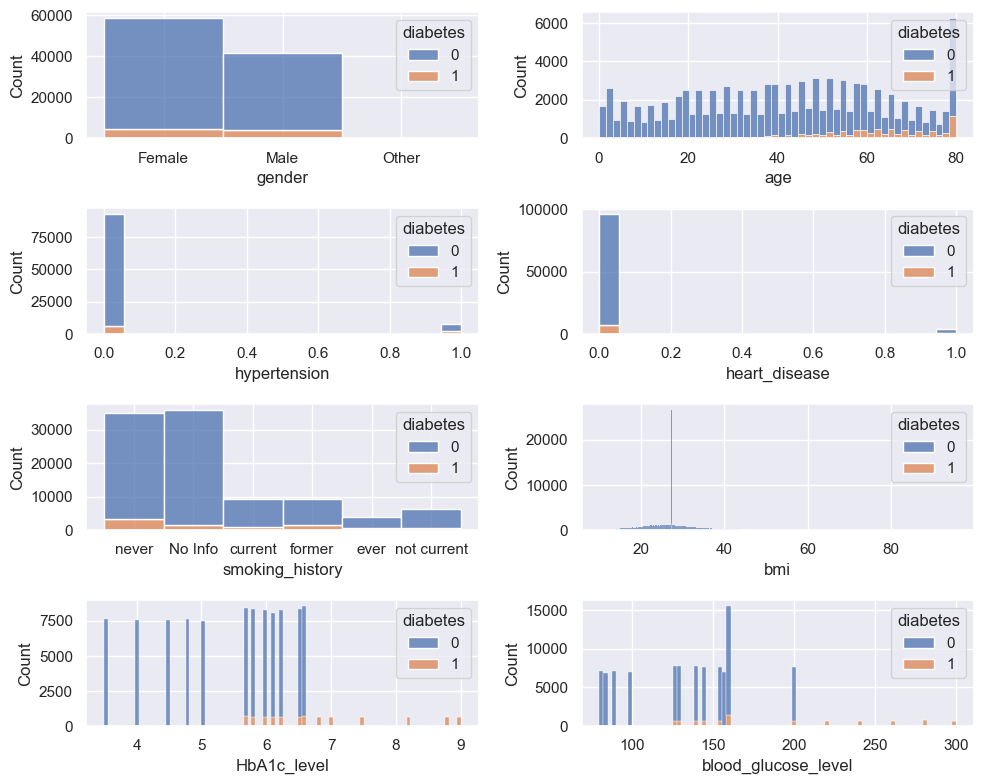

In [5]:
affiche_histogrammes(Xcol, df)

On remarque une surabondance de certaines valeurs dans les données de *bmi*, de *blood_glucose_level* et d'*age*. Il est possible que les pics des valeurs de *bmi* et de *blood_glucose_level* soient le résultat de l'imputation, par la moyenne ou la médiane, de valeurs manquantes dans la base de données originale. Cela biaise la distribution des données.

Dans le cas de l'âge, toutes les valeurs des patients plus âgés qu'une valeur seuil ont été placées dans le dernier intervalle, à droite. Cela biaise la distribution des données, mais ce n'est pas dû à de l'imputation de données manquantes.

Il arrive que l'affichage d'un histogramme avec un nombre trop faible d'intervalles (*bins*) regroupe plusieurs intervalles, ce qui produit des pics fictifs dans le résultat. C'est visiblement le cas avec les données d'*age*. Nous allons vérifier si les pics dans les histogrammes des données de *bmi* et de *blood_glucose_level* sont réels ou non en augmentant le nombre d'intervalles.

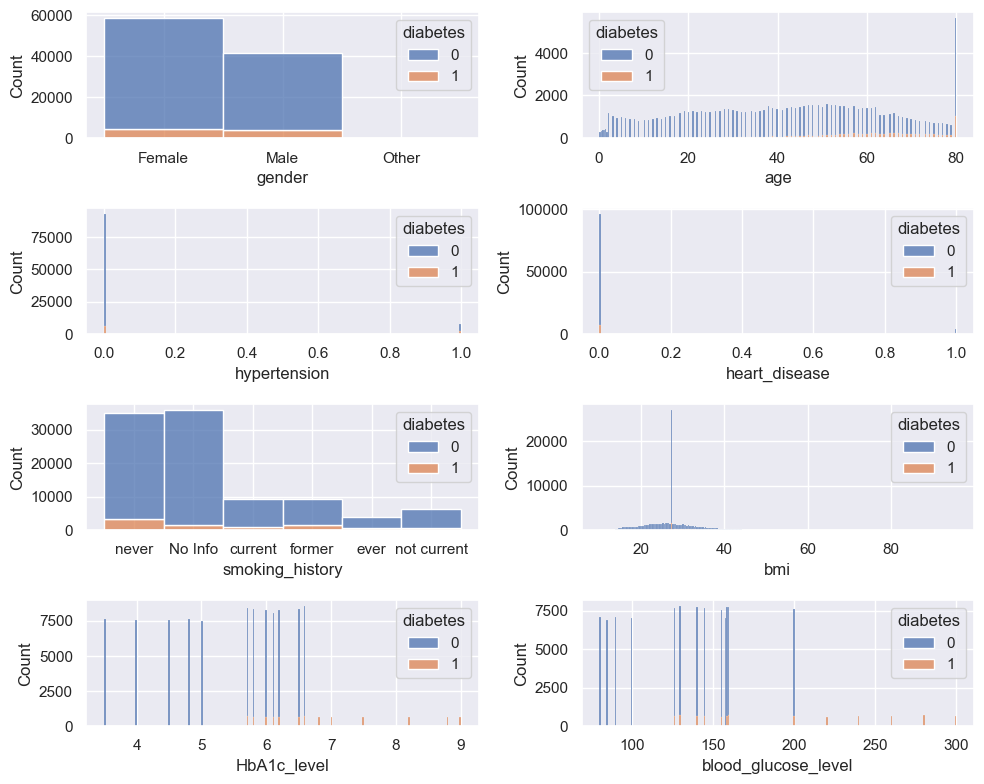

In [6]:
affiche_histogrammes(Xcol, df, bins=250)

Le pic des valeurs de *bmi* est toujours là, mais celui de *blood_glucose_level* a disparu! Ainsi, seul le pic de *bmi* résulte de l'imputation d'un grand nombre de données manquantes par une constante, ce qui biaise sa distribution des données.

Enfin, on remarque que certaines données *smoking_history* sont marquées « No info ». Il en va de même pour certaines données *genre* : la catégorie « Autre » est difficile à interpréter. Nous allons les remplacer plus loin dans le tutoriel.


### Nettoyage de la base de données

#### Élimination des doublons

<p>&nbsp;</p>
<div align="center">
    <img src= "Images/alice.jpeg"  width="300" />
</div>
<p>&nbsp;</p>

Les doublons sont des données répétées. Cela se produit lorsque des bases de données sont assemblées à partir d'autres bases de données pouvant se recouper entre elles. Il faut éliminer ces informations redondantes.

In [7]:
# Nombre de lignes avant suppression
n_before = df.shape[0]

# Suppression des doublons
df = df.drop_duplicates().reset_index(drop=True)

# Nombre de lignes après suppression
n_after = df.shape[0]

# Calcul du nombre et du pourcentage de doublons
n_duplicates = n_before - n_after
percentage = 100 * n_duplicates / n_before

print(f"Doublons supprimés : {n_duplicates} lignes ({percentage:.1f} %)")

Doublons supprimés : 3854 lignes (3.9 %)


#### Nettoyage des valeurs spéciales

Pour la caractéristique *gender*, on va remplacer des valeurs de **Other** avec les autres valeurs possibles (**Male** et **Female**) de façon stratifiée selon les valeurs de diabète. On fait la même chose pour la valeur de **No info** dans la caractéristique *smoking_history*.

Un remplacement stratifié signifie que les valeurs à éliminer respecteront la distribution statistique des autres valeurs présentes. Par exemple, si 60 % des personnes sont des femmes avec 10% de diabète et 40 % sont des hommes avec 8% de diabète, les valeurs de *Other* seront remplacées aléatoirement, tout en respectant cette répartition de selon le sexe et le taux de diabète.

In [8]:
def impute_placeholder(df, col, placeholder, strat):
    df = df.copy()
    for g in df[strat].unique():
        mask = (df[strat] == g) & (df[col] == placeholder)
        if mask.sum() == 0:
            continue
        dist = df.loc[(df[strat] == g) & (df[col] != placeholder), col].value_counts(normalize=True)
        df.loc[mask, col] = np.random.choice(dist.index, size=mask.sum(), p=dist.values)
    return df


# Appliquer la fonction pour 'gender'
df = impute_placeholder(df, 'gender', 'Other', 'diabetes')

# Appliquer la fonction pour 'smoking_history'
df = impute_placeholder(df, 'smoking_history', 'No Info', 'diabetes')

Affichage de l'histogramme de chaque variable pour observer l'effet du remplacement des valeurs **Other** dans *gender* et **No info** dans *smoking_history*.

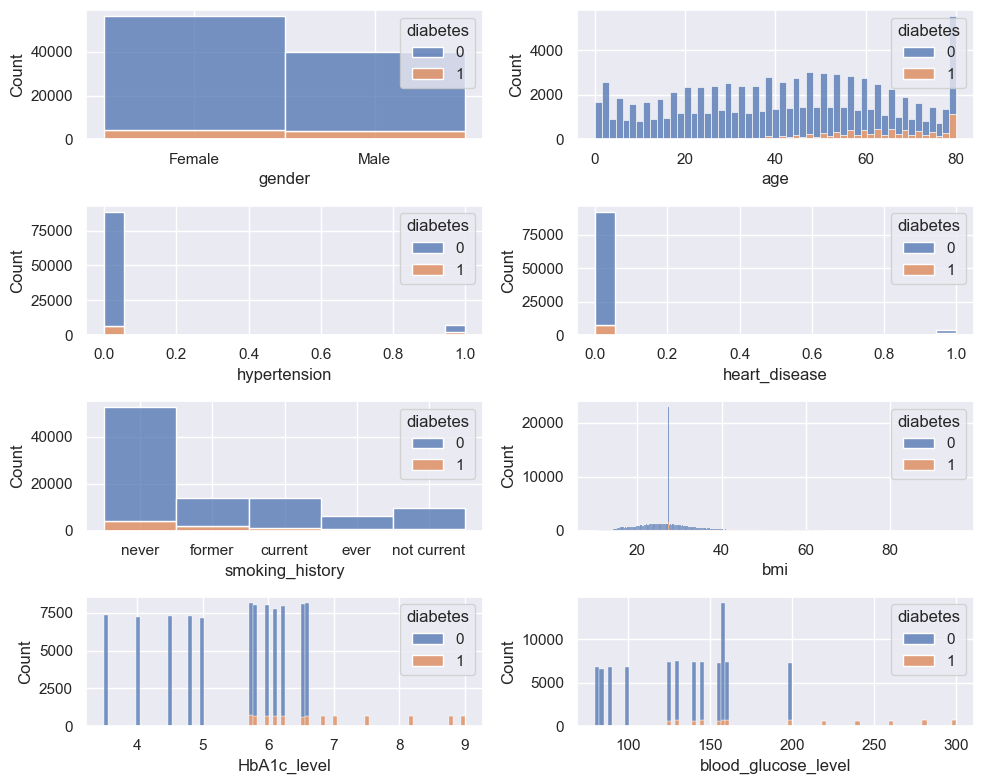

In [9]:
affiche_histogrammes(Xcol, df)

#### Détection des valeurs manquantes

<p>&nbsp;</p>
<div align="center">
    <img src= "Images/missing-data-illustration.jpeg"  width="300" />
</div>
<p>&nbsp;</p>

Les valeurs manquantes dans les bases de données sont souvent indiquées par des valeurs par défaut (*placeholders*) telles que NaN, 0, -1, 999, etc. Il faut faire attention, car les zéros peuvent correspondre à de vraies valeurs. Il faut alors vérifier.

In [65]:
print("=== 1) NaN explicites, i.e. indiqués tels quels ===")
missing_counts = df.isna().sum()
display(missing_counts)

print("\n=== 2) Valeurs minimales (détection de placeholders numériques) ===")
min_values = df.min()
display(min_values)

print("\nAnalyse des valeurs minimales :")
for col in df.columns:
    min_val = df[col].min()
    if min_val == 0:
        print(f" - {col}: 0 détecté (vérifier si c'est une valeur valide ou un placeholder)")


print("\n=== 3) Valeurs uniques dans les colonnes catégorielles ===")
for col in df.select_dtypes(include="object").columns:
    print(f"\n{col}:")
    print(df[col].value_counts())

=== 1) NaN explicites, i.e. indiqués tels quels ===


gender                 0
age                    0
smoking_history        0
hypertension           0
heart_disease          0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
dtype: int64


=== 2) Valeurs minimales (détection de placeholders numériques) ===


gender                    Male
age                         75
smoking_history        current
hypertension                 1
heart_disease                0
bmi                         35
HbA1c_level                  6
blood_glucose_level        200
dtype: object


Analyse des valeurs minimales :
 - heart_disease: 0 détecté (vérifier si c'est une valeur valide ou un placeholder)

=== 3) Valeurs uniques dans les colonnes catégorielles ===

gender:
gender
Male    1
Name: count, dtype: int64

smoking_history:
smoking_history
current    1
Name: count, dtype: int64


Tout est correct:
<ul>
<li>Il n'y a aucun NaN.</li>
<li>Toutes les valeurs 0 sont pertinentes</li>
<li>Il n'y a aucune valeur unique (e.g. Bozo, test, enlever, etc.).</li>
</ul>

#### Imputation des valeurs manquantes.

<p>&nbsp;</p>
<div align="center">
    <img src= "Images/imputation.jpeg"  width="300" />
</div>
<p>&nbsp;</p>

Comme on l'a vu avec la variable *bmi*, la base de données a déjà été prétraitée pour éliminer les valeurs manquantes multiples, mais pas pour la plupart des autres types de défauts rencontrés. Nous allons donc supprimer la valeur utilisée pour l'imputation. Cela permettra d'éviter plusieurs biais dans les données.

Remplaçons la valeur du mode de la caractéristique *bmi* avec des NaN. Nous les imputerons ensuite.

In [11]:
# Colonnes numériques utilisées pour l'imputation
num_cols = [
    'age',
    'hypertension',
    'heart_disease',
    'bmi',
    'HbA1c_level',
    'blood_glucose_level'
]


def clean_and_impute_bmi(df, num_cols):
    """
    Nettoie la variable 'bmi' en remplaçant la valeur imputée artificielle (le mode)
    par NaN, puis impute les NaN des colonnes numériques à l'aide d'un IterativeImputer
    basé sur XGBRegressor.

    Args:
        df (pd.DataFrame): Le DataFrame d'entrée.
        num_cols (list): Liste des colonnes numériques à imputer.

    Returns:
        pd.DataFrame: Le DataFrame nettoyé et imputé.
    """

    df = df.copy()

    # --- 1) Remplacement du mode de 'bmi' par NaN ---
    mode_bmi = df["bmi"].mode()[0]
    count_mode = (df["bmi"] == mode_bmi).sum()

    df.loc[df["bmi"] == mode_bmi, "bmi"] = np.nan

    print(f"Valeur imputée détectée dans 'bmi' : {mode_bmi}")
    print(f"Remplacement par NaN effectué pour {count_mode} lignes.")


    # --- 2) Imputation des NaN avec IterativeImputer (XGBRegressor) ---
    imputer = IterativeImputer(
        estimator=XGBRegressor(),
        max_iter=20,
        tol=1e-2,
        initial_strategy='median',
        verbose=True,
        random_state=0
    )

    # Imputation uniquement sur les colonnes numériques
    imputed_numeric = imputer.fit_transform(df[num_cols])

    # Remettre les valeurs imputées dans le DataFrame
    df[num_cols] = imputed_numeric

    print("\nImputation des NaN terminée pour les colonnes numériques.")

    return df

df = clean_and_impute_bmi(df, num_cols)

Valeur imputée détectée dans 'bmi' : 27.32
Remplacement par NaN effectué pour 21666 lignes.
[IterativeImputer] Completing matrix with shape (96146, 6)
[IterativeImputer] Change: 24.82619857788086, scaled tolerance: 3.0 
[IterativeImputer] Change: 0.0, scaled tolerance: 3.0 
[IterativeImputer] Early stopping criterion reached.

Imputation des NaN terminée pour les colonnes numériques.


Affichage de l'histogramme de chaque variable pour observer l'effet de l'élimination du pic artificiel dans *bmi*. L'élimination du pic fait apparaître la forme de la distribution des valeurs de *bmi*.

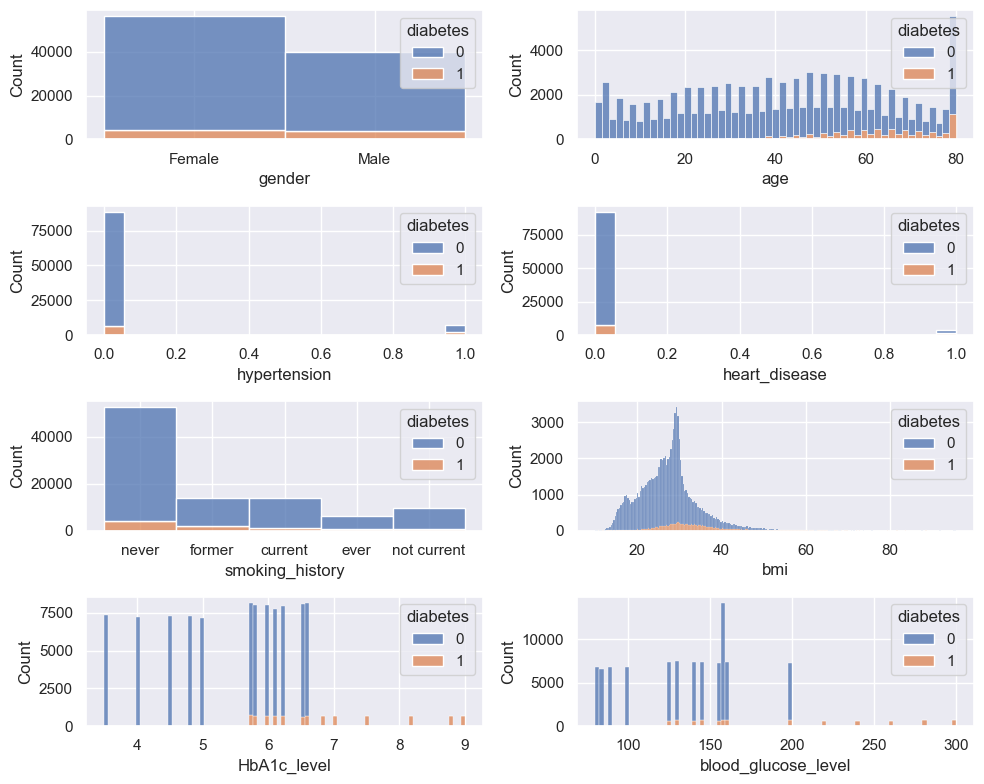

In [12]:
affiche_histogrammes(Xcol, df)

On remarque que la forme de la distribution de la variables *bmi* a changé puisque de nouvelles valeurs ont été introduites par l'imputation.

#### Détection et traitement des valeurs aberrantes

<p>&nbsp;</p>
<div align="center">
    <img src= "Images/fish-outlier.png"  width="300" />
</div>
<p>&nbsp;</p>

La méthode du facteur de valeur aberrante locale (LOF) est utilisée pour identifier les valeurs aberrantes.

On n'utilise pas les valeurs catégoriques ici. Les autres caractéristiques X doivent être normalisées.

In [13]:
# Copie de travail
df2 = df.copy()

# Colonnes numériques seulement
num_cols = [
    'age', 'hypertension', 'heart_disease', 'bmi',
    'HbA1c_level', 'blood_glucose_level'
]

# Normalisation robuste
scaler = RobustScaler()
df_scaled = scaler.fit_transform(df2[num_cols])

Calcul du score LOF

In [14]:
lof = LocalOutlierFactor(n_neighbors=10)
lof_scores = lof.fit_predict(df_scaled)  # labels (-1 = outlier)
lof_values = lof.negative_outlier_factor_

Affichage du score d'aberration. Les valeurs les plus négatives sont les plus aberrantes.

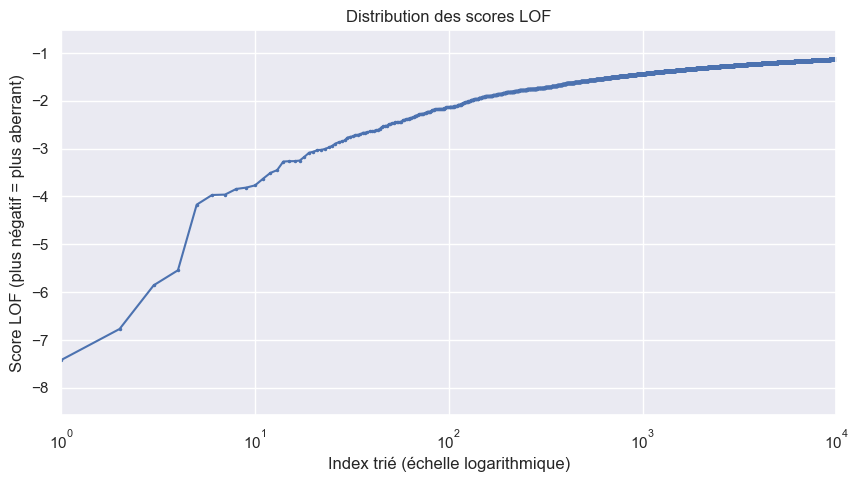

In [15]:
sorted_scores = np.sort(lof_values)

plt.figure(figsize=(10,5))
plt.plot(sorted_scores, '.-', markersize=3)
plt.xscale('log')
plt.xlim(1, 10000)
plt.grid(True)
plt.xlabel("Index trié (échelle logarithmique)")
plt.ylabel("Score LOF (plus négatif = plus aberrant)")
plt.title("Distribution des scores LOF")
plt.show()

La figure ci-dessus montre que les 4 premiers points ont une distribution légèrement différente par rapport au reste de la courbe. Tous les autres points varient peu de l'un à l'autre et ce jusqu'au dernier, vers 100,000.

Ça montre que la majorité des données aberrantes ont été éliminées dans la base de données originale. Il en restait encore quelques unes!

On élimine les 4 premiers points.


In [16]:
n_outliers = 5
threshold = sorted_scores[n_outliers-1]
print(f"Seuil LOF retenu : {threshold:.3f}")

Seuil LOF retenu : -5.545


Élimination des valeurs aberrantes.

In [17]:
mask = lof_values >= threshold
df_clean = df[mask].reset_index(drop=True)

print(f"Données initiales : {df.shape[0]}")
print(f"Données conservées : {df_clean.shape[0]}")
print(f"Points éliminés : {df.shape[0] - df_clean.shape[0]}")

Données initiales : 96146
Données conservées : 96142
Points éliminés : 4


Séparation des noms de variables en entrées X et en sortie Y.

In [18]:
Xcol = df.drop(['diabetes'], axis=1).columns.to_list()
Ycol = 'diabetes'

Affichage de l'histogramme final des variables nettoyées

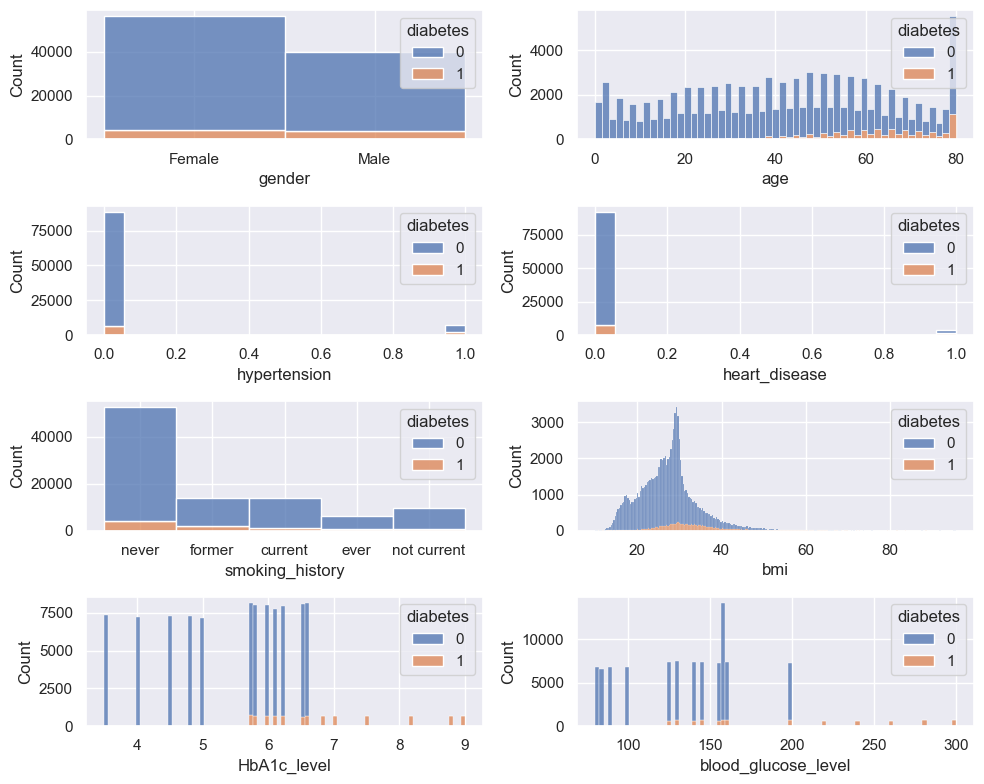

In [19]:
affiche_histogrammes(Xcol, df)

La figure ci-dessus monte l'histogramme de chaque caractéristique X incluant les données des sujets sains (bleu) et diabétiques (orange).

On remarque les points suivants:
<ol>
<li>le risque de diabète augmente avec l'âge, le bmi, le taux de HbAlc et celui de glucose,</li>
<li>les données pour les taux de HbAlc et de glucose sont mesurées à des valeurs discrètes spécifiques.</li>
</ol>

<div style="
    background-color:#fff3cd;
    border-left:6px solid #ffecb5;
    padding:20px;
    border-radius:6px;
">
<h2 style="margin-top:0; font-weight:bold;">
⚠️ ATTENTION
</h2>

<p style="font-size:1.4em; font-weight:bold;">
Voici une section fondamentale du tutoriel.
<br><br>
</p>
</div>

---
## Partie II: Classification binaire des données du diabète
---

<p>&nbsp;</p>
<div align="center">
    <img src= "Images/classifier-model.png"  width="500" />
</div>
<p>&nbsp;</p>


### Séparation des noms de variables en entrées X et en sortie Y.

In [20]:
target_col = "diabetes"
feature_cols = df.columns.drop(target_col).tolist()

X = df[feature_cols]
y = df[target_col]

print(f"Nombre de variables explicatives : {len(feature_cols)}")
print(f"Variable cible : {target_col}")

Nombre de variables explicatives : 8
Variable cible : diabetes


#### Séparation stratifiée des données en ensembles d'entraînement et de test

On utilise la répartition standard de 80% des données pour l'entraînement et 20% des données pour le test. La séparation est stratifiée afin d'avoir la même fraction de sujets diabétiques dans les deux ensembles.

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=SEED
)

print(f"Taille de X_train : {X_train.shape}")
print(f"Taille de X_test  : {X_test.shape}")
print(f"\nDistribution du diabète dans y_train :\n{y_train.value_counts(normalize=True)}")
print(f"\nDistribution du diabète dans y_test  :\n{y_test.value_counts(normalize=True)}")

Taille de X_train : (76916, 8)
Taille de X_test  : (19230, 8)

Distribution du diabète dans y_train :
diabetes
0   0.91
1   0.09
Name: proportion, dtype: float64

Distribution du diabète dans y_test  :
diabetes
0   0.91
1   0.09
Name: proportion, dtype: float64


Vérification pour voir s'il n'y a pas de fuite de données entre les ensembles. Cela se produit lorsque plusieurs données se retrouvent dans les deux ensembles en même temps.

La fuite de données est l’une des erreurs les plus graves en apprentissage automatique :
- elle fausse les performances ;
- elle rend le modèle irréaliste ;
- elle invalide toute évaluation ;
- elle peut être difficile à détecter visuellement.

Il n'y en a pas dans cet exemple, mais il faut le vérifier par précaution. S'il y en avait, il faudrait éliminer les copies.

In [22]:
assert X_train.index.isin(X_test.index).sum() == 0, "Fuite de données détectée!"

### Définition d'un pipeline de traitement des données

Dans cette section nous allons discuter de plusieurs types de prétraitement des données appliquées à des données déjà nettoyées.  Nous allons faire trois types de prétraitement

<ul>
<li>Le balancement des classes,</li>
<li>La normalisation des données,</li>
<li>Le traitement des données catégoriques.</li>
</ul>

#### Le balancement des classes


<p>&nbsp;</p>
<div align="center">
    <img src= "Images/data-scale.jpeg"  width="200" />
</div>
<p>&nbsp;</p>

Il est fréquent qu'il y ait un déséquilibre entre les classes dans une base de données : la classe qui nous intéresse le plus (« classe 1 ») est souvent la plus rare. On observe alors un déséquilibre entre les classes.

En apprentissage automatique (AA), l'exactitude (*accuracy*) est une mesure de qualité en classification. Il existe plusieurs autres mesures de qualité, mais l'exactitude est la plus intuitive. Elle représente la proportion de prédictions correctes (positives et négatives) par rapport à l'ensemble des prédictions.

Que se passe-t-il dans les modèles lorsque l'entraînement est effectué sur un jeu de données déséquilibré ? Lorsqu'un modèle obtient une exactitude de 99 % avec des données déséquilibrées (99 % des instances appartiennent à la « classe 0 »), c'est parce qu'il examine les données et décide intelligemment de toujours prédire « classe 0 » pour atteindre une grande exactitude.

Est-ce si mauvais que ça ? Oui ! Pensez-y. Dans la pratique, ce sont les instances de la classe rarissime (« classe 1 ») qui nous intéressent réellement. Le classificateur précédent ne pourrait en détecter aucune dans un jeu de données ne contenant que des instances rarissimes !

### La normalisation des données

La normalisation des données est une transformation qui élimine les différents ordres de grandeur et les différentes unités des variables numériques. Ça facilite l'entraînement de beaucoup de modèles en apprentissage automatique. Ceux basés sur les arbres décisionnels (forêts aléatoires, XGBoost, AdaBoost, etc.) y sont insensibles, mais les performances des modèles linéaires (régression linéaire, régression logistique, SVM) en dépendent grandement.

<p>&nbsp;</p>
<div align="center">
    <img src= "Images/normalisation.png"  width="300" />
</div>
<p>&nbsp;</p>


Dans cet exemple, nous allons utiliser le modèle XGBoost qui est basé sur des arbres décisionnels. La normalisation des données n'est pas nécessaire ici, mais nous allons tout de même la réaliser, car c'est une bonne habitude à prendre.

#### Définition du pipeline de traitement des données

In [23]:
# Caractéristiques/variables numériques
num_cols = [
    'age', 'hypertension', 'heart_disease', 'bmi',
    'HbA1c_level', 'blood_glucose_level'
]

# Caractéristiques/variables catégorielles
cat_cols = ['gender', 'smoking_history']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols), # Normalisation
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='if_binary'), cat_cols) # Transformation des données catégorielles
    ]
)

pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('smote', SMOTE(random_state=SEED)),
    ('model', XGBClassifier())
])

#### Affichage des distributions des classes de sujets sains et diabétiques.

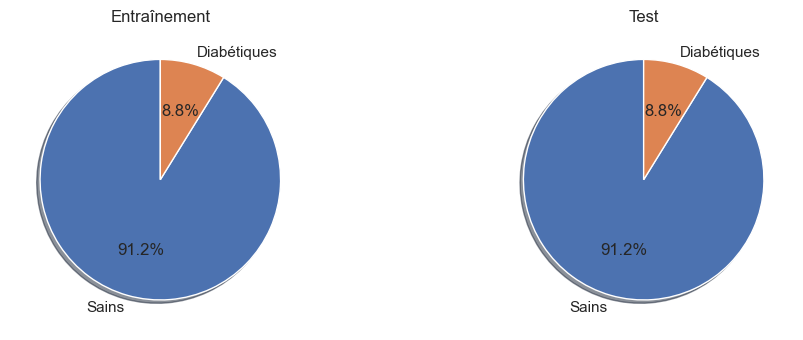

In [24]:
# Fonction d'affichage de 'Pie Charts'
def affiche (y_train, y_test):
    labels = ['Sains', 'Diabétiques']
    sizes_train = [*y_train.value_counts()]
    sizes_test = [*y_test.value_counts()]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    fig.tight_layout(pad=2.0)

    # Ensemble d'entraînement
    ax1.pie(sizes_train, labels=labels, autopct='%1.1f%%',
            shadow=True, startangle=90)
    ax1.set_title("Entraînement")
    ax1.set_aspect('equal')

    # Ensemble de test
    ax2.pie(sizes_test, labels=labels, autopct='%1.1f%%',
            shadow=True, startangle=90)
    ax2.set_title("Test")
    ax2.set_aspect('equal')

    plt.show()

affiche (y_train, y_test)

La valeur de 8,8% correspond bien à celle observée dans la [population canadienne]( https://www.canada.ca/fr/sante-publique/services/publications/maladies-et-affections/cadre-diabete-canada.html#a4). En effet,
plus de 3 millions de Canadiens, soit 8,9 % de la population, ont reçu un diagnostic de diabète (2017).

Les deux ensembles de données sont déséquilibrés. Nous allons uniquement balancer celui d'entraînement.

Pourquoi balancer l'ensemble d'entraînement? Voici comment on peut le voir : En les équilibrant, on offre au classificateur les meilleures chances possibles de bien les différencier, ce qui améliore les performances des modèles d'apprentissage automatique. Ce n'est pas toujours le cas lorsque le débalancement est faible, mais nous allons le faire dans ce cas-ci.

Pourquoi ne pas balancer l'ensemble de test? Parce qu'on ne peut pas s'attendre à ce que les données du monde réel soient équilibrées lorsqu'on va déployer un modèle. On veut ainsi obtenir les performances réelles du modèle dans la pratique.

Montrons l'effet du balancement des classes du jeu d'entraînement avec la méthode [SMOTE](https://imbalanced-learn.org/dev/references/generated/imblearn.over_sampling.SMOTE.html).

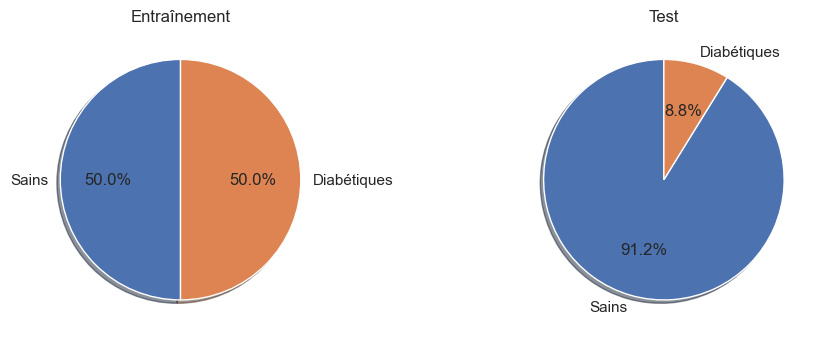

In [25]:
# 1. Prétraitement (fit_transform)
X_train_pre = pipeline.named_steps['preprocess'].fit_transform(X_train)
X_test_pre = pipeline.named_steps['preprocess'].transform(X_test)

# 2. SMOTE (fit_resample)
X_train_bal, y_train_bal = pipeline.named_steps['smote'].fit_resample(
    X_train_pre, y_train
)

# 3. Visualisation
affiche(y_train_bal, y_test)

Les classes des sujets sains et diabétiques sont maintenant balancées uniquement pour l'ensemble d'entraînement.

---
### Entraînement et optimisation d'un classificateur XGBoost
---

<p>&nbsp;</p>
<div align="center">
    <img src= "Images/7749808022_e4e2a1271c_b.jpg"  width="400" />
</div>
<p>&nbsp;</p>

Une fois les données prétraitées, on peut passer à l'étape d'entraînement du classificateur.
Il existe plusieurs types de classificateurs. Plutôt que de choisir son modèle préféré, il est recommandé d'en entraîner plusieurs, car leurs performances peuvent varier considérablement d'une base de données à l'autre. On choisit ensuite le meilleur parmi eux. Comme mentionné dans l'introduction, par souci de temps de calcul, nous n'en utiliserons qu'un seul : XGBoost, qui est souvent le plus performant.

### Choix des hyperparamètres (HP)

Chaque classificateur comporte son lot d'hyperparamètres à ajuster. Toutefois, le nombre d'HP ayant le plus grand impact sur les résultats est assez restreint. On en sélectionne quelques-uns pour chaque classificateur à tester. Il est souvent possible de trouver sur Internet ou en utilisant un chatbot quels sont les meilleurs paramètres à utiliser pour un modèle donné.

Quelle méthode d'optimisation utiliser? La figure suivante en compare trois
<ul>
<li>sur grille,</li>
<li>aléatoire, </li>
<li>bayésienne.</li>
</ul>  

La figure montre, en couleur, la fonction à optimiser. Dans ce cas, on cherche la position $(x_1, x_2)$ du minimum. Les points noirs indiquent les combinaisons d'hyperparamètres utilisées. Contrairement aux deux premières méthodes, la méthode bayésienne apprend de ses essais et erreurs. Elle modélise la fonction à optimiser et suggère une nouvelle combinaison d'HP proche de l'optimum recherché. C'est ce que montre la figure suivante : Notez les positions des essais successifs dans le dernier panneau. Elles se rapprochent graduellement du minimum global, situé en bas à gauche. Les performances s'améliorent ainsi au fil des essais.


<p>&nbsp;</p>
<div align="center">
    <img src= "Images/heatmap.001-min.jpeg"  width="500" />
</div>
<p>&nbsp;</p>

Notez que la recherche Bayésienne n'est pas toujours la meilleure si le nombre d'essais est faible. De plus, elle prend plus de temps à effectuer. Par contre lorsqu'il y a beaucoup de données à traiter, par exemple 100 000 plutôt que 1000, cette approche est préférable aux approches sur grille et aléatoire. Le temps d'entraînement d'un modèle devient alors plus long que le temps requis pour déterminer le nouvel ensemble d'HP à tester.

Pour une comparaison plus détaillée des diverses approches, jetez un coup d'oeil à cet [article](https://arxiv.org/pdf/2104.10201.pdf).

Définissons une fonction qui entraîne un modèle avec la méthode bayésienne. On utilise la populaire librairie Optuna pour optimiser les hyperparamètres. Nous allons maximiser le score F1 plutôt que l'exactitude.

In [27]:
def optuna_optimize_model(
    model_class, params, X_train, y_train, X_test, y_test,
    n_trials=50, base_params=None, seed=SEED
):
    import copy
    from sklearn.metrics import f1_score

    # Paramètres fixes selon le modèle
    if base_params is None:
        base_params = {}

    # Paramètres fixes spécifiques à XGBoost CPU
    if model_class.__name__ == "XGBClassifier":
        base_params = {
            **base_params,
            "tree_method": "hist",
            "nthread": -1,
            "random_state": seed,
            "early_stopping_rounds": 50   # early stopping ici !
        }

    def objective(trial):
        trial_params = {}

        # Génération des hyperparamètres Optuna
        for name, spec in params.items():
            ptype = spec[0]

            if ptype == "int":
                trial_params[name] = trial.suggest_int(name, spec[1], spec[2])

            elif ptype == "float":
                trial_params[name] = trial.suggest_float(name, spec[1], spec[2])

            elif ptype == "loguniform":
                trial_params[name] = trial.suggest_float(name, spec[1], spec[2], log=True)

            elif ptype == "categorical":
                trial_params[name] = trial.suggest_categorical(name, spec[1])

        # Fusion des paramètres fixes + Optuna
        full_params = copy.deepcopy({**base_params, **trial_params})

        # Instanciation du modèle
        model = model_class(**full_params)

        # Entraînement
        if model_class.__name__ == "XGBClassifier":
            model.fit(
                X_train, y_train,
                eval_set=[(X_test, y_test)],
                verbose=False
            )
        else:
            model.fit(X_train, y_train)

        # Attention! On maximise le score F1 plutôt que l'exactitude.
        preds = model.predict(X_test)
        score = f1_score(y_test, preds)

        return score

    # Étude Optuna avec pruner
    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=seed),
        pruner=optuna.pruners.MedianPruner()
    )

    study.optimize(objective, n_trials=n_trials)

    # Reconstruction du meilleur modèle
    best_params = {**(base_params or {}), **study.best_params}
    best_model = model_class(**best_params)

    if model_class.__name__ == "XGBClassifier":
        best_model.fit(
            X_train, y_train,
            eval_set=[(X_test, y_test)],
            verbose=False
        )
    else:
        best_model.fit(X_train, y_train)

    return study.best_value, study.best_params, best_model

Définissons l'espace de recherche des hyperparamètres. Selon Copilot, les hyperparamètres les plus optimisés avec Optuna pour la fonction XGBClassifier sont dans la majorité des notebooks, articles et benchmarks :
1. learning_rate
2. max_depth
3. min_child_weigh
4. subsample
5. colsample_bytree
6. gamma
7. n_estimators

Ce sont ceux qui modifient le plus la performance.

In [28]:
# Espace de recherche optimisé pour XGBClassifier tel que suggéré par Copilot en se basant sur
# le nombre de données et le nombre de caractéristiques (*features*) dans celles-ci.
params_xgb = {
    "learning_rate": ("loguniform", 1e-3, 0.2),
    "max_depth": ("int", 3, 10),
    "min_child_weight": ("int", 1, 10),
    "subsample": ("float", 0.6, 1.0),
    "colsample_bytree": ("float", 0.6, 1.0),
    "gamma": ("float", 0.0, 5.0),
    "n_estimators": ("int", 200, 800)
}

# Entraînement de plusieurs modèles XGBoost avec différentes combinaisons d'hyperparamètres, puis sélection du meilleur.
score_xgb, best_params_xgb, best_model_xgb = optuna_optimize_model(
    XGBClassifier,
    params_xgb,
    X_train_bal, y_train_bal,
    X_test_pre, y_test,
    n_trials=30,
    base_params={"tree_method": "hist", "random_state": SEED}
)

print("XGBoost - Score F1 :", score_xgb)
print("XGBoost - Meilleurs paramètres :", best_params_xgb)

[I 2026-02-23 15:50:56,650] A new study created in memory with name: no-name-505e018b-af6a-4d07-ab16-b4e6c5593835
[I 2026-02-23 15:51:00,325] Trial 0 finished with value: 0.6587550380653829 and parameters: {'learning_rate': 0.0037790512775899344, 'max_depth': 3, 'min_child_weight': 7, 'subsample': 0.6173877942579008, 'colsample_bytree': 0.6465694812666125, 'gamma': 3.0193284447440654, 'n_estimators': 314}. Best is trial 0 with value: 0.6587550380653829.
[I 2026-02-23 15:51:06,616] Trial 1 finished with value: 0.7859025032938075 and parameters: {'learning_rate': 0.03453621330596442, 'max_depth': 10, 'min_child_weight': 5, 'subsample': 0.7329039400190971, 'colsample_bytree': 0.7132134540686906, 'gamma': 0.931411336991122, 'n_estimators': 390}. Best is trial 1 with value: 0.7859025032938075.
[I 2026-02-23 15:51:14,055] Trial 2 finished with value: 0.6506334550139575 and parameters: {'learning_rate': 0.012799221057940258, 'max_depth': 3, 'min_child_weight': 8, 'subsample': 0.72587077359181

XGBoost - Score F1 : 0.7948293006297646
XGBoost - Meilleurs paramètres : {'learning_rate': 0.08616575672833289, 'max_depth': 4, 'min_child_weight': 2, 'subsample': 0.9397973290295702, 'colsample_bytree': 0.9940176072917386, 'gamma': 0.7382996004445841, 'n_estimators': 519}


#### Pipeline final pour l'inférence uniquement

In [66]:
# On désactive early stopping pour l'inférence
best_model_xgb.set_params(early_stopping_rounds=None)

pipeline_final = Pipeline(steps=[
    ('preprocess', preprocessor),          # Transformations identiques
    ('smote', 'passthrough'),              # SMOTE ne doit PAS être appliqué en prédiction
    ('model', best_model_xgb)              # Modèle déjà entraîné
])

### Affichage du rapport de classification pour le modèle optimal

<p>&nbsp;</p>
<div align="center">
    <img src= "Images/human-character.jpeg"  width="300" />
</div>
<p>&nbsp;</p>

Le rapport de classification présente les scores de précision, de rappel, et de F1 pour les classes Diabétiques (« classe 1 ») et Sains (« classe 0 »).

In [67]:
from sklearn.metrics import classification_report

y_pred = pipeline_final.predict(X_test)

print(classification_report(
    y_test,
    y_pred,
    target_names=['Sains', 'Diabétiques']
))

              precision    recall  f1-score   support

       Sains       0.97      0.99      0.98     17534
 Diabétiques       0.91      0.71      0.79      1696

    accuracy                           0.97     19230
   macro avg       0.94      0.85      0.89     19230
weighted avg       0.97      0.97      0.97     19230



Définitions:
<ul>
<li>precision: fraction des prédictions correctes pour une classe donnée.</li>
<li>recall (rappel): fraction des sujets d'une classe donnée qu'on a détectés. </li>
<li>f1-score: combinaison des deux précédentes valeurs.</li>
<li>accuracy: fraction de bonne prédictions pour les deux classes.</li>
</ul>

Observations:
<ul>
<li>Parmi toutes nos prédictions de sujets atteints de diabète, 91 % l'étaient vraiment.</li>
<li>On a détecté 71 % des sujets diabétiques.</li>
<li>97 % des prédictions (sujets avec ou sans diabète) étaient correctes.</li>
</ul>

Détecter seulement 71 % des sujets diabétiques ne semble pas beaucoup, mais il faut se rappeler que ceux-ci ne constituent qu'environ 9 % des données totales! Le classificateur est capable de trouver 71 % des aiguilles dans la botte de foin des sujets testés!

Le modèle a une exactitude (*accuracy*) de 97 %. Cela signifie que 97 % de ses prédiction (diabétiques ou sains) sont exactes. Pensez-y, si le modèle prédisait toujours la classe la plus probable (91 % des sujets sont sains), il n'aurait eu qu'une exactitude de 91 % alors qu'il atteint maintenant 97 %!

### Faire une prédiction pour un nouveau sujet

Beaucoup d'exemples sur le web montrent comment optimiser les performances d'un classificateur, ou de plusieurs en même temps, afin de sélectionner le meilleur d'entre eux. Toutefois, ils montrent rarement comment utiliser ensuite ce classificateur sur de nouvelles données.

<p>&nbsp;</p>
<div align="center">
    <img src= "Images/exam.png"  width="400" />
</div>
<p>&nbsp;</p>


Soit un sujet ayant les caractéristiques suivantes:

<ul>
<li><b>gender</b> : Male,</li>
<li><b>age</b> : 75,</li>
<li><b>smoking_history</b> : current,</li>
<li><b>hypertension</b> : 1,</li>
<li><b>heart_disease</b> : 0,</li>
<li><b>bmi</b> : 35,</li>
<li><b>HbA1c_level</b> : 6,</li>
<li><b>blood_glucose_level</b> : 200.</li>
</ul>

In [68]:
# Profil du sujet
df = pd.DataFrame(
    {
     'gender': ['Male'],
     'age': [75],
     'smoking_history': ['current'],
     'hypertension': [1],
     'heart_disease': [0],
     'bmi': [35],
     'HbA1c_level': [6],
     'blood_glucose_level': [200]
    }
)

# La probabilité d'être diabétique est calculée en utilisant le pipeline final de traitement des données.
proba = pipeline_final.predict_proba(df)[0, 1]
print(f"Probabilité estimée de diabète : {np.round(100*proba)} %")

Probabilité estimée de diabète : 67.0 %


<div style="
    background-color:#fff3cd;
    border-left:6px solid #ffecb5;
    padding:20px;
    border-radius:6px;
">
<h2 style="margin-top:0; font-weight:bold;">
⚠️ ATTENTION
</h2>

<p style="font-size:1.4em; font-weight:bold;">
Voici une section fondamentale du tutoriel.
<br><br>
</p>
</div>

---
## Partie III: Interprétabilité des résultats de classification du diabète
---

<p>&nbsp;</p>
<div align="center">
    <img src= "Images/medecine-personel.png"  width="300" />
</div>
<p>&nbsp;</p>


Dans cette partie, nous verrons comment interpréter les prédictions d'un classificateur permettant d'identifier les sujets diabétiques.

Voici la partie généralement la plus intéressante pour quelqu'un à la recherche des facteurs responsables du diabète. Maintenant qu'on a un classificateur, que peut-il nous apprendre sur les variables importantes?

Les données ont été nettoyées dans la première partie. Elles ont ensuite servi à entraîner un classificateur dans la seconde partie. Nous allons maintenant utiliser une méthode d'interprétabilité pour mieux comprendre les prédictions et voir comment elles dépendent des caractéristiques des sujets étudiés (âge, sexe, etc.).

### La méthode de Shapley

Les valeurs SHAP (*SHapley Additive exPlanations*) représentent la contribution (positive ou négative) de chaque variable à la prédiction d'un modèle. La somme de toutes les contributions équivaut à la réponse $y$ du modèle.

Dans le cas du diabète, les valeurs positives augmentent le risque et les valeurs négatives le diminuent.


### Préparation des données pour cette partie

#### Features nettoyées et des valeurs cibles à prédire

In [69]:
X_all = pd.concat([X_train, X_test]).reset_index(drop=True)
y_all = pd.concat([y_train, y_test], axis=0).reset_index(drop=True)

#### Données prétraitées (encodées + normalisées)

In [70]:
# Prétraitement identique à celui du pipeline
X_all_pre = preprocessor.transform(X_all)

#### Noms des colonnes après OneHotEncoder.

Il faut connaître les noms des colonnes transformées.

In [71]:
# Colonnes numériques
num_cols = [
    'age', 'hypertension', 'heart_disease', 'bmi',
    'HbA1c_level', 'blood_glucose_level'
]

# Colonnes catégorielles encodées
ohe = preprocessor.named_transformers_['cat']
cat_encoded_cols = ohe.get_feature_names_out(['gender', 'smoking_history'])

# Colonnes finales
feature_names = list(num_cols) + list(cat_encoded_cols)

### Calcul des valeurs SHAP pour le modèle XGBoost optimisé

On va calculer les valeurs SHAP à partir du modèle final (dans le pipeline) après entrainement.

In [72]:
# On récupère le modèle XGBoost entraîné
model_xgb = pipeline_final.named_steps['model']

# On crée l'explainer SHAP spécifique aux modèles basés sur des arbres de décision, comme XGBoost.
# Cette étape est parfois longue à effectuer lorsqu'il y a beaucoup de données et de caractéristiques.
explainer = shap.TreeExplainer(model_xgb)

# Calcul des valeurs SHAP pour toutes les observations prétraitées
shap_values = explainer.shap_values(X_all_pre)

print("SHAP values shape :", np.array(shap_values).shape)

SHAP values shape : (96146, 12)


N.B. Les données sont maintenant en 12 dimensions.

Affichons maintenant l'importance de chaque variable, en ordre décroissant.

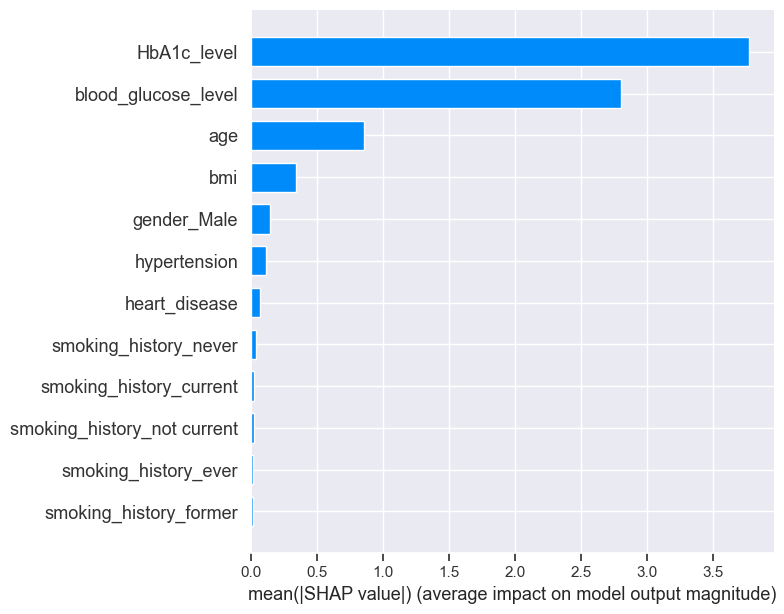

In [73]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_all_pre, feature_names=feature_names, plot_type="bar")
plt.show()

La protéine HbA1c est la variable la plus importante, suivie du taux de glucose, de l'âge et de l'indice de masse corporelle. L'importance des variables restantes diminue ensuite rapidement. Les variables suivantes ont un effet négligeable sur le diabète par rapport aux quatre premières.

Affichons maintenant le *Beeswarm Plot* qui montre la distribution et la direction des effets.

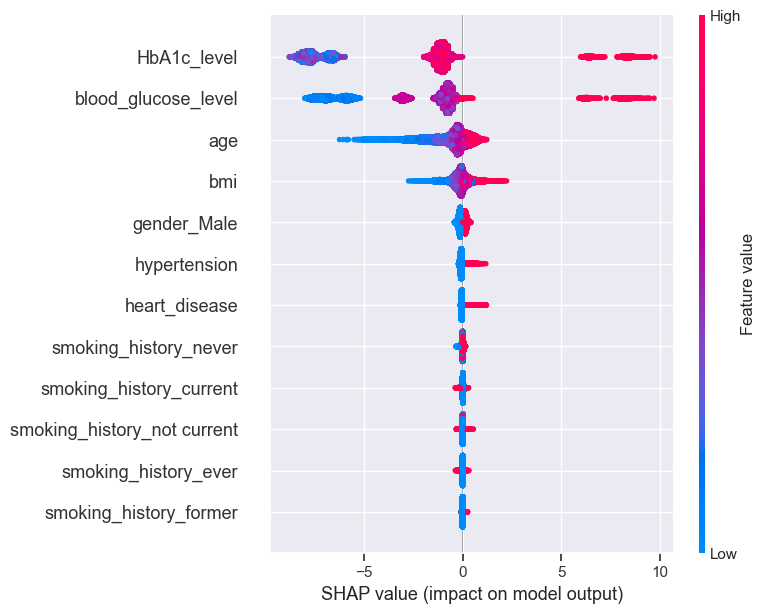

In [74]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_all_pre, feature_names=feature_names)
plt.show()

La figure semble intimidante et complexe au premier abord, mais comme on dit souvent, *la familiarité vient avec l'usage*.

Ce qu'il faut retenir:
<ul>
<li>L'échelle de couleurs correspond à la valeur numérique de chaque variable, faible (bleu) et forte (rouge).</li>

<li>Plus une variable a une valeur SHAP positive, plus elle augmente la probabilité de diabète. </li>

<li>Plus une variable a une valeur SHAP négative, plus elle diminue la probabilité de diabète.</li>

<li>Sur chaque ligne, il y a autant de points que de sujets dans la base de données (environ 100 K ici).</li>
</ul>

Regardons la variable *age*. Les points bleus correspondent à des personnes jeunes ayant une faible probabilité de diabète. C'est l'inverse pour les personnes agées (en rouge).

Voilà comment expliquer cette étrange figure.

#### Faire une prédiction pour un nouveau sujet

Dans la seconde partie, nous avons vu comment prédire la probabilité de diabète d'un individu à partir de ses caractéristiques physiques et de variables mesurées lors d'un examen médical. Le modèle avait prédit une probabilité de 63,8 % sans fournir d'explications. Le médecin et son patient aimeraient savoir quelles variables ont déterminé ce résultat. L'analyse précédente ne permettait pas d'y répondre. L'analyse de Shapley permet de répondre à cette question, comme nous allons le voir.

Reprenons les caractéristiques du patient.

In [75]:
# Profil du sujet
df_sujet = pd.DataFrame(
    {
     'gender': ['Male'],
     'age': [75],
     'smoking_history': ['current'],
     'hypertension': [1],
     'heart_disease': [0],
     'bmi': [35],
     'HbA1c_level': [6],
     'blood_glucose_level': [200]
    }
)

In [76]:
# 1. Prédiction "classique" via le pipeline
proba_pipeline = pipeline_final.predict_proba(df_sujet)[0, 1]
print(f"Probabilité de diabète calculée via pipeline : {100*proba_pipeline:.1f} %")

Probabilité de diabète calculée via pipeline : 66.7 %


Utilisons maintenant l'approche descriptive de Shapley.

In [77]:
# 1. Prétraitement du sujet via le pipeline
X_sujet_pre = pipeline_final.named_steps['preprocess'].transform(df_sujet)

# 2. Récupération du modèle XGBoost
model_xgb = pipeline_final.named_steps['model']

# 3. Explainer SHAP
explainer = shap.TreeExplainer(model_xgb)

# 4. Valeurs SHAP pour cet individu
shap_sujet = explainer.shap_values(X_sujet_pre)[0]

# 5. Valeur de base (expected value)
base_value = explainer.expected_value

Affichons le diagrame *Waterfall* qui montre la contribution de chaque variable à la probabilité de diabète.

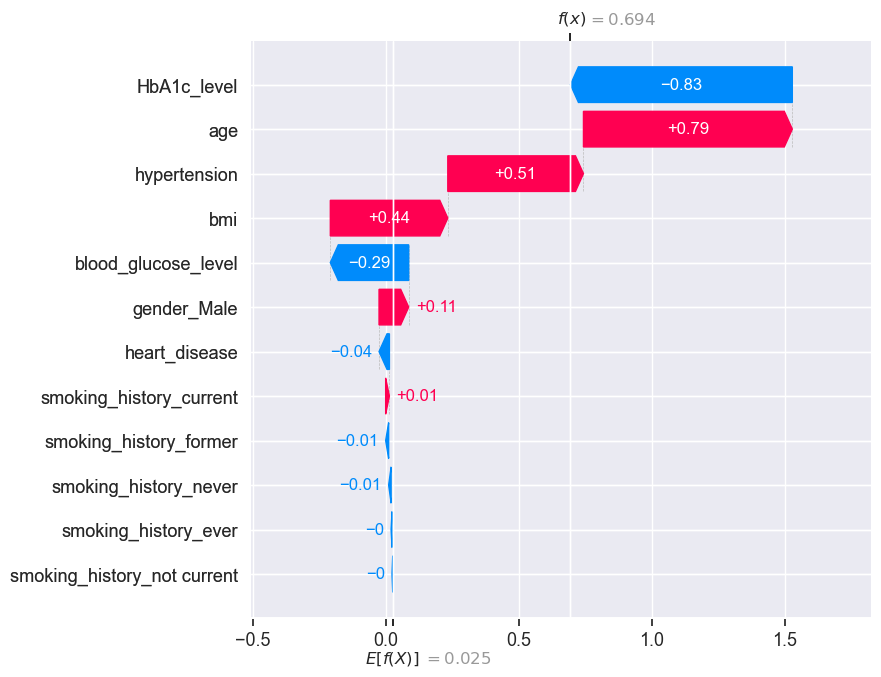

In [78]:
plt.figure(figsize=(10, 6))
shap.plots._waterfall.waterfall_legacy(
    base_value,
    shap_sujet,
    feature_names=feature_names,
    max_display=20
)
plt.show()

<p>&nbsp;</p>
<div align="center">
    <img src= "Images/inspector-with-magnifying-glass.jpeg"  width="200" />
</div>
<p>&nbsp;</p>

On constate que son âge, son surpoids (indiqué par un BMI > 30) et son hypertension ont augmenté ses risques de diabète (marqueurs rouges), mais que ses faibles taux de HbA1c et de glucose les ont réduits (marqueur bleu). Le fait d'être un homme a très légèrement augmenté ses risques de diabète.

In [79]:
# Calcul de la probabilité de diabète via SHAP : base_value + somme des SHAP → logit → probabilité
logit_shap = base_value + shap_sujet.sum()
proba_shap = 1 / (1 + np.exp(-logit_shap))

print(f"Probabilité via SHAP : {100*proba_shap:.1f} %")

Probabilité via SHAP : 66.7 %


### Comment les caractéristiques individuelles influencent-elles la probabilité de développer un diabète ?

Il est plus intéressant encore d'afficher la relation entre les valeurs SHAP et une variable donnée. Cela met en évidence la relation souvent complexe (i.e. nonlinéaire) entre la variable et la maladie. C'est une information cruciale pour un chercheur étudiant le diabète.

Préparons d'abord les données pour les mettre sous une forme utile au type de visualisation que l'on recherche.

In [80]:
# 1. Colonnes numériques brutes
df_num = X_all[num_cols].reset_index(drop=True)

# 2. Colonnes catégorielles brutes
df_cat = X_all[['gender', 'smoking_history']].reset_index(drop=True)

# 3. Reconstruction des colonnes OHE avec valeurs brutes
df_ohe_display = pd.DataFrame()

for col in cat_encoded_cols:
    # Exemple :
    #   gender_Female → gender
    #   smoking_history_never → smoking_history
    original_col = '_'.join(col.split('_')[:-1])
    df_ohe_display[col] = df_cat[original_col]

# 4. Assemblage final dans l'ordre exact de feature_names
X_all_shap_display = pd.concat([df_num, df_ohe_display], axis=1)
X_all_shap_display = X_all_shap_display[feature_names]

#### Affichage de l'effet des principales caractéristiques sur la probabilité de diabète

Pour une figure donnée, on voit la relation entre chaque caractéristique et la valeur SHAP associée. La couleur montre l'effet de l'interaction principale avec la caractéristique affichée.


=== SHAP dependence plot pour : HbA1c_level ===


<Figure size 1200x800 with 0 Axes>

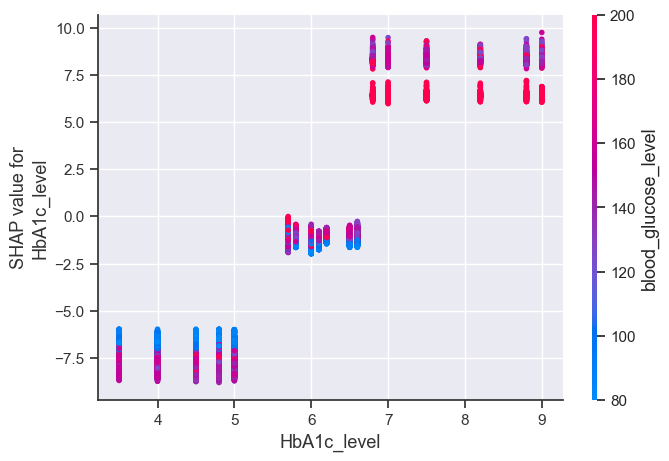


=== SHAP dependence plot pour : blood_glucose_level ===


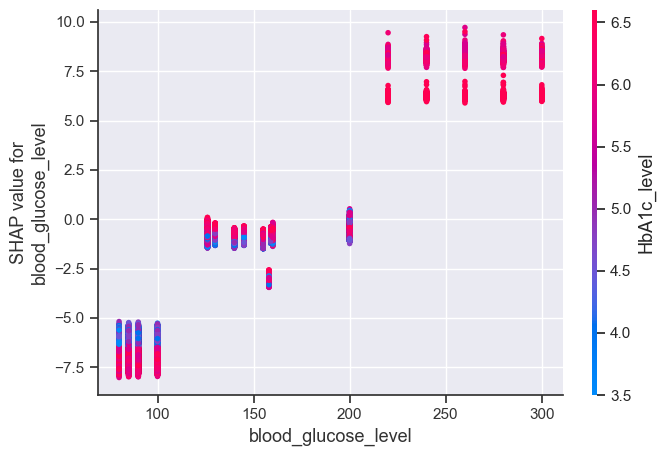


=== SHAP dependence plot pour : age ===


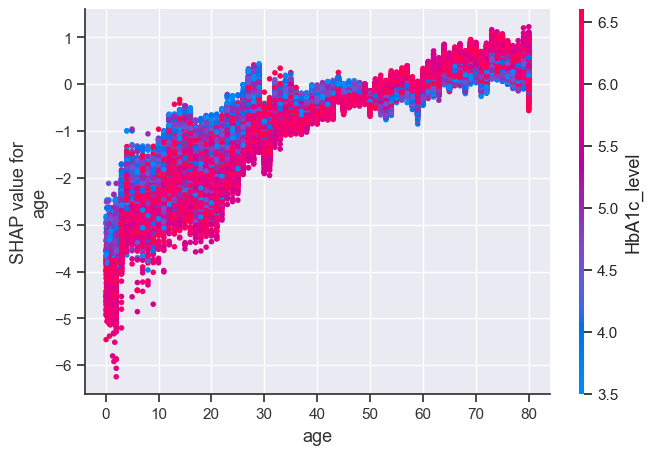


=== SHAP dependence plot pour : bmi ===


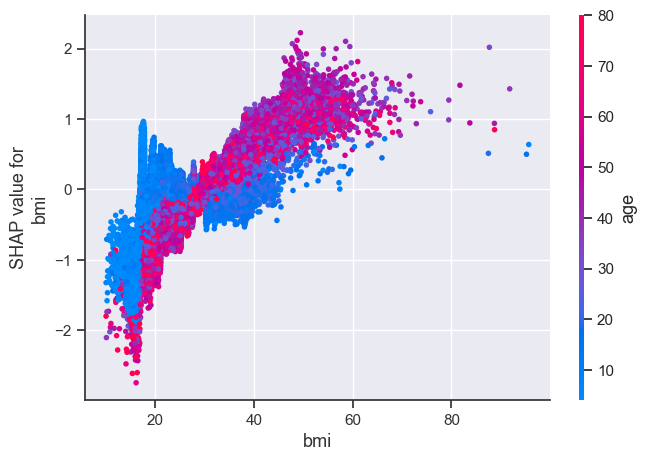

In [81]:
variables_cibles = [
    'HbA1c_level',
    'blood_glucose_level',
    'age',
    'bmi'
]

plt.figure(figsize=(12, 8))

for var in variables_cibles:
    print(f"\n=== SHAP dependence plot pour : {var} ===")
    shap.dependence_plot(
        var,
        shap_values,
        X_all_shap_display,   # <-- valeurs brutes alignées avec shap_values
        feature_names=feature_names,
        interaction_index="auto"
    )

Les deux premières figures montrent que les variables *HbA1c_level* et *blood_glucose_level* sont mesurées à des valeurs discrètes, contrairement aux variables *age* et *bmi*.

La troisième figure montre que le risque de diabète augmente avec l'âge et le taux d'hémoglobine *HbA1c*. La dernière figure montre que le risque de diabète augmente lorsque le *bmi*>30, c'est-à-dire chez les personnes obèses et plus âgées.

**Pensez-y!** Notre analyse nous a permis de faire tout ceci:

<ul>
<li>On a identifié les variables associées au diabète.</li>
<li>On a montré comment chaque variable affectait le risque de diabète.</li>
<li>On a pu faire une prédiction sur le risque de diabète pour personne à la fois.</li>
<li>On a déterminé qu'elles étaient les variables qui ont déterminé son risque de diabète!</li>
</ul>

<div style="
    background-color:#fff3cd;
    border-left:6px solid #ffecb5;
    padding:20px;
    border-radius:6px;
">
<h2 style="margin-top:0; font-weight:bold;">
⚠️ ATTENTION
</h2>

<p style="font-size:1.4em; font-weight:bold;">
Voici une section fondamentale du tutoriel.
<br><br>
</p>
</div>

## Partie IV: Réduction de la dimensionnalité et regroupement des données

<p>&nbsp;</p>
<div align="center">
    <img src= "Images/people-height.jpeg"  width="600" />
</div>
<p>&nbsp;</p>

Les plongements de données (*data embeddings*) permettent de réduire leur dimensionnalité, ce qui facilite souvent leur analyse et leur visualisation. On utilise la méthode UMAP pour effectuer les plongements de données.

Le regroupement des données (*cluster analysis*) permet de créer des sous-groupes contenant des informations similaires. Ils facilitent non seulement l'analyse des données, mais aussi l'interprétation des résultats. On utilise la méthode DBSCAN pour effectuer les regroupements de données.

Dans cette section, nous allons poursuivre l'exploration des données sur le diabète en utilisant les valeurs SHAP plutôt que les variables originales, afin de bénéficier de l'explicabilité des résultats. Cette méthode est souvent utilisée après l'entraînement d'un modèle en apprentissage automatique, qu'il s'agisse d'un classificateur ou d'un régresseur.

Calculons les valeurs de Shapley sous une forme légèrement différente de celle dans la partie précédente. Cela va nous permettre de faire les plongements de données.

In [82]:
explainer = shap.TreeExplainer(model_xgb, model_output="raw")

# Calcul des valeurs SHAP pour l'ensemble de test
shap_values = explainer.shap_values(X_all_pre)

On normalise les valeurs de Shapley pour faciiliter les opérations qui suivent.

In [83]:
scaler_shap = StandardScaler()
shap_values_scaled = scaler_shap.fit_transform(shap_values)

### Génération d'une projection UMAP 2-D des valeurs SHAP.

Observons ce que l'on obtient lorsque l'on transforme des données 12-D en 2-D. Pourrons-nous y discerner des groupes de données, et donc des groupes de sujets ayant des caractéristiques similaires ?

#### Projections des données 12-D en 2-D

Définissons d'abord une fonction permettant de faire des plongements en utilisant la méthode UMAP. Le nombre de composantes *n_components* est la dimension finale, par exemple 2-D ou 3-D.

La fonction utilise un plongement UMAP **supervisé**. Elle utilise ainsi les vraies classes, déjà connues, pour guider le plongement UMAP qui rapproche les points de même classe et sépare les classes si les valeurs SHAP le permettent. Les clusters deviennent ainsi plus nets. UMAP apprend une structure discriminante. 

In [84]:
def plongement(
    X, y, N_e=10000, n_neighbors=30, min_dist=0.1, n_components=2, seed=42
):

    rng = np.random.default_rng(seed)

    idx_0 = np.where(y == 0)[0]
    idx_1 = np.where(y == 1)[0]

    ratio_minoritaire_cible = 0.4
    n_1 = int(N_e * ratio_minoritaire_cible)
    n_0 = N_e - n_1

    idx_0_sub = rng.choice(idx_0, size=min(n_0, len(idx_0)), replace=False)
    idx_1_sub = rng.choice(idx_1, size=min(n_1, len(idx_1)), replace=False)

    idx_sub = np.concatenate([idx_0_sub, idx_1_sub])
    rng.shuffle(idx_sub)

    X_sub = X[idx_sub]
    y_sub = y[idx_sub]

    umap_model = umap.UMAP(
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        n_components=n_components,
        metric="euclidean",
        init="spectral",
        random_state=seed,
        transform_seed=seed,
        negative_sample_rate=1,
        local_connectivity=1,
        n_epochs=1000,
    )

    X_sub_embedded = umap_model.fit_transform(X_sub, y=y_sub)
    X_embedded = umap_model.transform(X)

    return X_embedded

La cellule suivante prend plusieurs minutes à s'exécuter.

In [85]:
shap_umap_2D_scaled = plongement(shap_values_scaled, y_all, N_e=10000, n_neighbors=300, min_dist=1, n_components=2)

Affichage de la projection 2-D des valeurs SHAP.

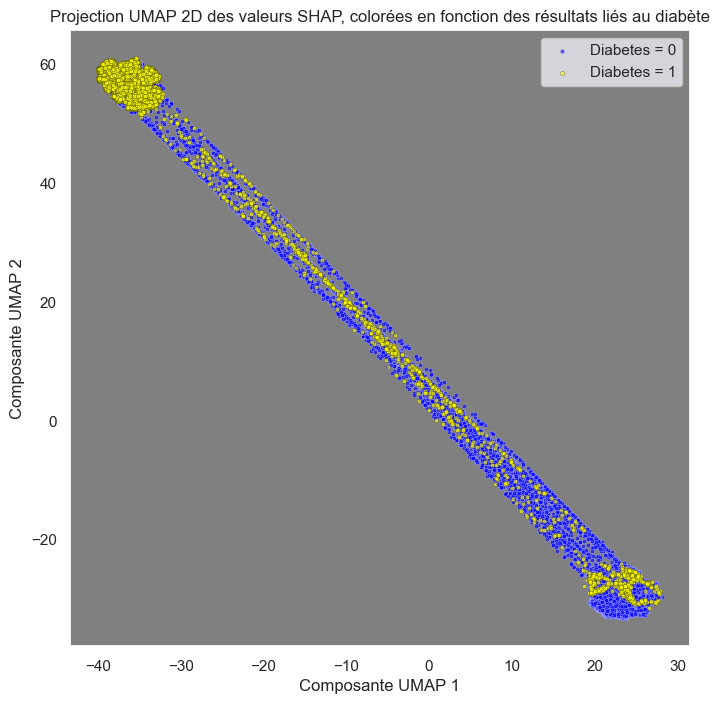

In [50]:
plt.figure(figsize=(8, 8))
ax = plt.gca()
ax.set_facecolor('gray')

# Séparer les points selon la classe
umap_class_0 = shap_umap_2D_scaled[y_all == 0]
umap_class_1 = shap_umap_2D_scaled[y_all == 1]

# Afficher les points selon la couleur de la vraie classe
plt.scatter(umap_class_0[:, 0], umap_class_0[:, 1], s=10, alpha=0.6, color='blue', edgecolor="white", linewidth=0.25, label='Diabetes = 0')
plt.scatter(umap_class_1[:, 0], umap_class_1[:, 1], s=10, alpha=0.6, color='yellow', edgecolor="black", linewidth=0.25, label='Diabetes = 1')

plt.title("Projection UMAP 2D des valeurs SHAP, colorées en fonction des vraies classes")
plt.xlabel("Composante UMAP 1")
plt.ylabel("Composante UMAP 2")
plt.grid(False)
plt.legend() # Ajouter une légende pour différencier les classes


plt.show()

Notez qu'il y a trois zones particulières. Deux amas sont séparés par un pont. La majorité des sujets sains et diabétiques sont assez bien séparés, mais pas parfaitement. Une séparation parfaite aurait été surprenante ; les points formant le pont appartiennent probablement à des sujets dont la probabilité de diabète se situe quelque part entre 10 % et 90 %. Les points bleus dans l'amas jaune et les points jaunes dans l'amas bleu sont probablement des sujets mal classés selon leurs valeurs SHAP. Les classes affichées sont les **vraies**, et non celles prédites.

### Regroupement des données 2-D

La méthode DBSCAN est utilisée pour isoler les différents groupes. Cette méthode dépend principalement de deux hyperparamètres (*eps* et *min_samples*) qui contrôlent la qualité des regroupements. Dans la pratique, il faut les optimiser le plus précisément possible ; les valeurs actuelles ont été obtenues par essais et erreurs pour obtenir trois groupes.

Les méthodes DBSCAN et HDBSCAN sont puissantes, mais parfois difficiles à utiliser. L'ajustement de leurs hyperparamètres n'est pas toujours aisé, et il faut se fier aux projections UMAP en deux ou trois dimensions pour se faire une idée du nombre de clusters recherchés.

In [86]:
dbscan = DBSCAN(eps=1.2, min_samples=40)

clusters_scaled = dbscan.fit_predict(shap_umap_2D_scaled)

# Compter le nombre de groupes; les données qui n'appartiennent pas à des
# groupes (outliers) ne sont pas affichées.
unique_clusters = set(clusters_scaled)
if -1 in unique_clusters:
    unique_clusters.remove(-1)
n_clusters_scaled = len(unique_clusters)

print(f"Nombre de groupes en projection 2-D: {n_clusters_scaled}")

Nombre de groupes en projection 2-D: 3


Affichage des regroupements observés. Chacun est identifié par une couleur différente. Les outliers sont des points qui n'appatiennent pas à un groupe donné. Ils apparaissent en noir à la frontière entre des groupes différents.

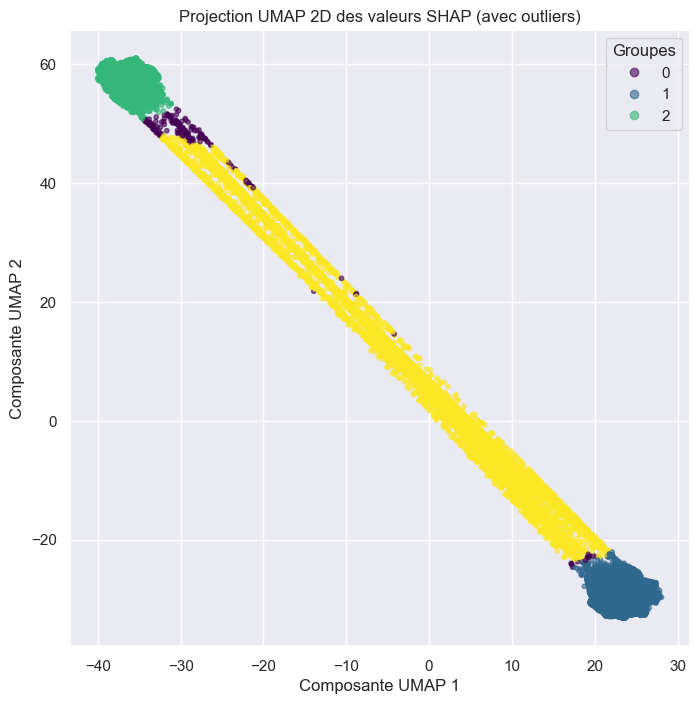

In [87]:
plt.figure(figsize=(8, 8))

# On utilise les étiquettes des amas pour colorer les points.
scatter = plt.scatter(shap_umap_2D_scaled[:, 0], shap_umap_2D_scaled[:, 1], s=10, alpha=0.6, c=clusters_scaled, cmap='viridis')
plt.title("Projection UMAP 2D des valeurs SHAP (avec outliers)")
plt.xlabel("Composante UMAP 1")
plt.ylabel("Composante UMAP 2")
plt.legend(handles=scatter.legend_elements()[0], labels=unique_clusters, title="Groupes")
plt.grid(True)
plt.show()

Enlevons les outliers pour mieux différencier les différents groupes.

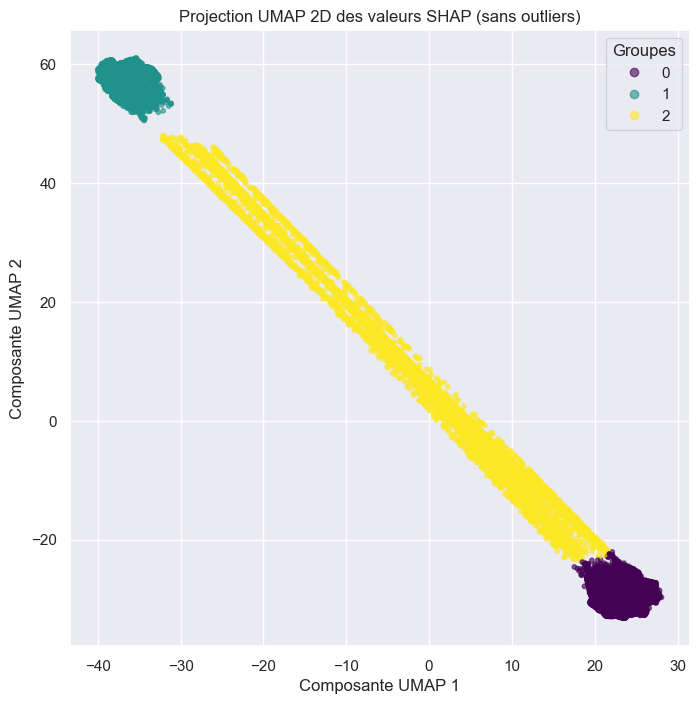

In [88]:
plt.figure(figsize=(8, 8))

# Les points outliers ne sont pas affichés.
non_outliers_mask = clusters_scaled != -1
shap_umap_2D_scaled_filtered = shap_umap_2D_scaled[non_outliers_mask]
clusters_scaled_filtered = clusters_scaled[non_outliers_mask]

# On utilise les étiquettes des amas pour colorer les points.
scatter = plt.scatter(shap_umap_2D_scaled_filtered[:, 0], shap_umap_2D_scaled_filtered[:, 1], s=10, alpha=0.6, c=clusters_scaled_filtered, cmap='viridis')
plt.title("Projection UMAP 2D des valeurs SHAP (sans outliers)")
plt.xlabel("Composante UMAP 1")
plt.ylabel("Composante UMAP 2")
plt.legend(handles=scatter.legend_elements()[0], labels=unique_clusters, title="Groupes")
plt.grid(True)
plt.show()

### Analyse démographique des différents groupes

Générons un tableau contenant les statistiques sur les nombres de sujets dans chaque groupe.

In [89]:
df_test_for_histograms = pd.concat([X_all, y_all], axis=1)

cluster_summary_data = []

# Obtenir tous les identifiants de cluster uniques, à l'exclusion des valeurs aberrantes (-1)
all_unique_clusters = np.unique(clusters_scaled)
non_outlier_clusters = [c for c in all_unique_clusters if c != -1]

# Calculer le nombre total de sujets dans tous les clusters non aberrants pour le calcul du pourcentage
non_outlier_mask = (clusters_scaled != -1)
total_subjects_in_all_clusters = len(df_test_for_histograms[non_outlier_mask])

for cluster_id in non_outlier_clusters:
    cluster_mask = (clusters_scaled == cluster_id)
    df_cluster = df_test_for_histograms[cluster_mask].copy()

    if not df_cluster.empty:
        total_subjects_in_cluster = len(df_cluster)
        diabetic_subjects_in_cluster = df_cluster["diabetes"].sum ()

        percentage_diabetic_in_cluster = (diabetic_subjects_in_cluster / total_subjects_in_cluster) * 100
        percentage_of_total_clustered = (total_subjects_in_cluster / total_subjects_in_all_clusters) * 100

        cluster_summary_data.append({
            "Cluster ID": cluster_id,
            "% Diabétiques": f"{percentage_diabetic_in_cluster:.2f} %",
            "% du total groupé": f"{percentage_of_total_clustered:.2f} %"
        })
    else:
        cluster_summary_data.append({
            "Cluster ID": cluster_id,
            "% Diabétiques": "N/A",
            "% du total groupé": "0.00%"
        })

cluster_summary_df = pd.DataFrame(cluster_summary_data)
display(cluster_summary_df)

,Cluster ID,% Diabétiques,% du total groupé
0,0,0.55 %,80.33 %
1,1,73.04 %,10.50 %
2,2,7.58 %,9.16 %


Le groupe 0 contient presque 100 % de sujets sains.

Le groupe 1 contient 73 % de sujets diabétiques. Il représente environ 11 % des sujets de l'analyse, assez près de la proportion de 8,8 % observée dans la population.

Le groupe 2 représente le pont. 

#### Pourquoi n'avons nous pas 100 % de sujets sains dans le groupe 0 et 100 % de sujets diabétiques dans le groupe 1?

<p>&nbsp;</p>
<div align="center">
    <img src= "Images/inspector-with-magnifying-glass.jpeg"  width="200" />
</div>
<p>&nbsp;</p>

Reproduisons à nouveau le rapport de classification obtenu après l'entrainement du modèle XGBoost optimal dans la partie II.

In [90]:
y_pred = pipeline_final.predict(X_test)

print(classification_report(
    y_test,
    y_pred,
    target_names=['Sains', 'Diabétiques']
))

              precision    recall  f1-score   support

       Sains       0.97      0.99      0.98     17534
 Diabétiques       0.91      0.71      0.79      1696

    accuracy                           0.97     19230
   macro avg       0.94      0.85      0.89     19230
weighted avg       0.97      0.97      0.97     19230



Selon ce rapport, le modèle XGBoost a permis d'identifier 71 % des personnes diabétiques et 99 % des personnes saines.

Selon le résumé précédent, le groupe 1, correspondant aux personnes diabétiques, est composé de 73 % de diabétiques. Cela indique que le modèle n'en a détecté que 73 %, soit près de la valeur de rappel de 71 % indiquée précédemment. De façon similaire, le groupe 0, correspondant aux sujets sains, est constitué à 99,45 % de sujets sains, ce qui est proche de la valeur de rappel de 99 % indiquée précédemment. Voilà pourquoi les deux groupes ne sont pas constitués uniquement de points bleus ou jaunes ; le classificateur n'est pas parfait. Il commet des erreurs faciles à identifier dans la projection UMAP colorée selon les vraies classes. On comprend ainsi mieux la signification du rappel, qui correspond au pourcentage d'objets détectés pour une classe donnée.

#### Définissons une fonction qui affiche les histogrammes des caractéristiques X dans un groupe donné.

In [91]:
def plot_cluster_histograms(cluster_id, data_df, clusters_array, Xcol):
    """
    Extrait les données d'un groupe donné et génère des histogrammes pour chaque caractéristique.

    Args:
        cluster_id (int): L'identifiant du groupe à extraire.
        data_df (pd.DataFrame): Le DataFrame contenant les données à filtrer (doit correspondre à clusters_array).
        clusters_array (np.ndarray): Le tableau des identifiants de groupe pour chaque point.
        Xcol (list): La liste des noms de colonnes des caractéristiques.
    """
    print(f"Affichage des histogrammes pour le Cluster {cluster_id}")

    # Masque pour sélectionner les données du cluster spécifié
    cluster_mask = (clusters_array == cluster_id)

    # Filtrer le DataFrame pour obtenir uniquement les données de ce cluster
    df_cluster = data_df[cluster_mask].copy()

    # Appeler la fonction affiche_histogrammes avec les données du cluster
    if not df_cluster.empty:
        affiche_histogrammes(Xcol, df_cluster)
    else:
        print(f"Le cluster {cluster_id} ne contient aucune donnée.")

Nous allons maintenant afficher les histogrammes des caractéristiques pour les trois groupes. Dans la section sur l'interprétabilité des résultats, nous avons vu que les variables les plus importantes sont

<ul>
<li><b>HbA1c Level</b> : taux de HbA1c (type d’hémoglobine) dans le sang,</li>
<li><b>Blood Glucose Level</b> : taux de glucose dans le sang,</li>
<li><b>Age</b> : âge des sujets,</li>
<li><b>Body Mass Index (BMI)</b> : indice de masse corporelle (IMC),</li>
</ul>

Cela devrait se refléter dans la variabilité des histogrammes correspondants. Les histogrammes des autres variables devraient peu varier.

#### Affichage des histogrammes pour les sujets du groupe 0.

Affichage des histogrammes pour le Cluster 0


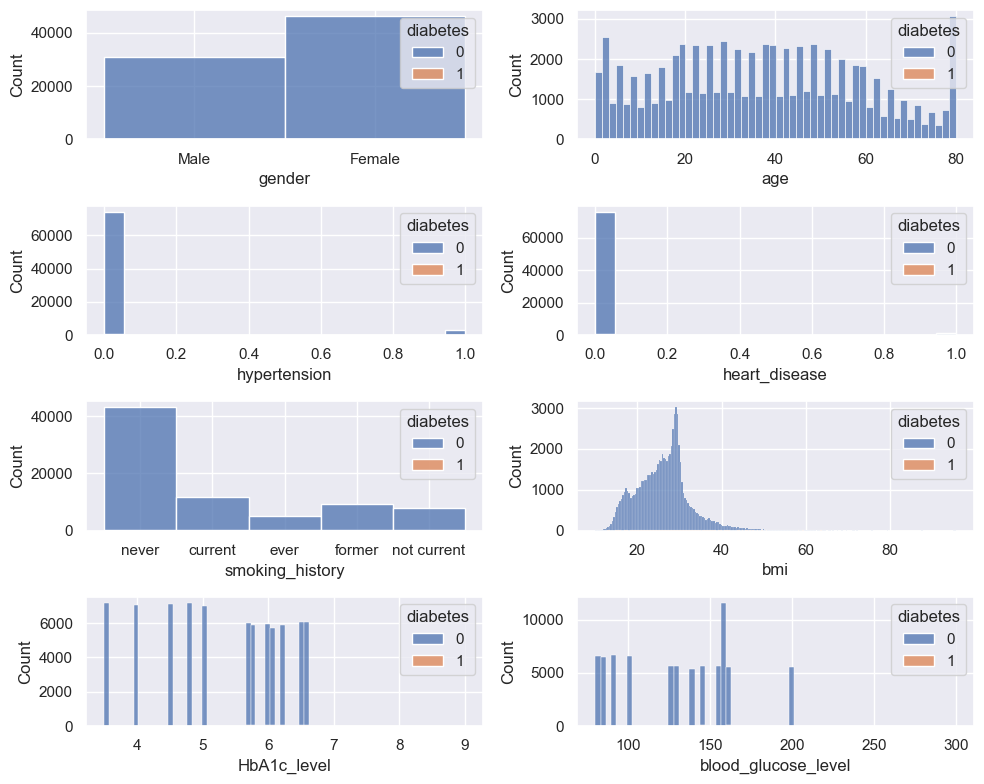

In [92]:
plot_cluster_histograms(0, df_test_for_histograms, clusters_scaled, Xcol)

Le groupe 0 constitue l'amas des sujets sains. 

#### Affichage des histogrammes pour les sujets dans le groupe 1.

Affichage des histogrammes pour le Cluster 1


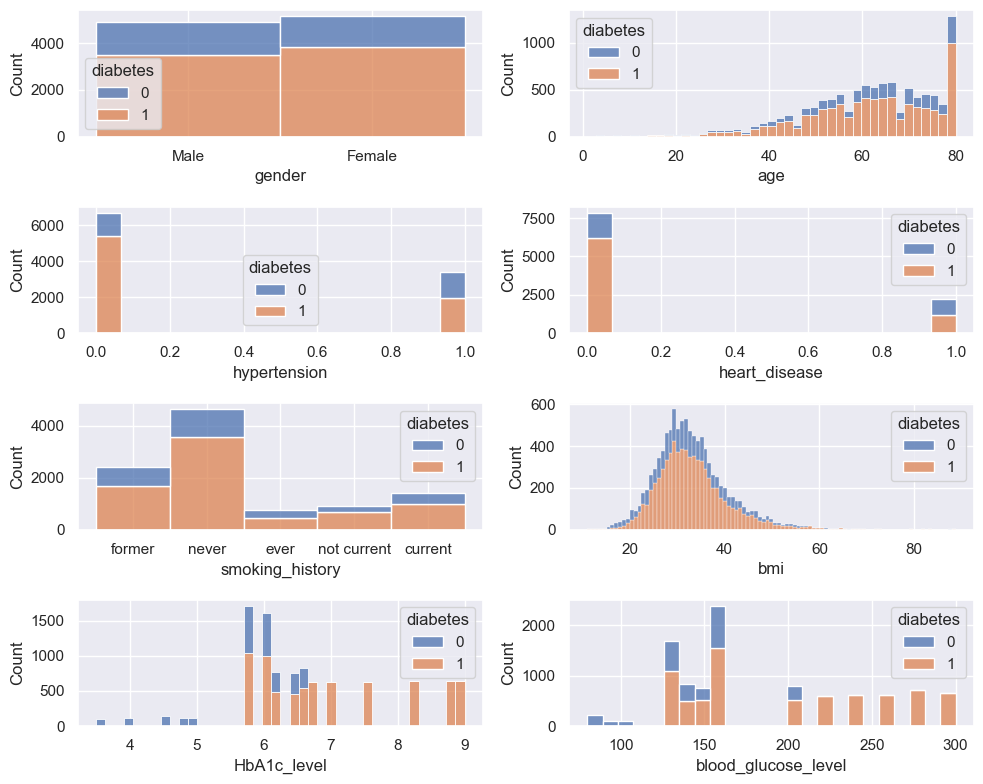

In [93]:
plot_cluster_histograms(1, df_test_for_histograms, clusters_scaled, Xcol)

Le groupe 1 constitue l'amas des sujets diabétiques.

#### Affichage des histogrammes pour les sujets dans le groupe 2.

Affichage des histogrammes pour le Cluster 2


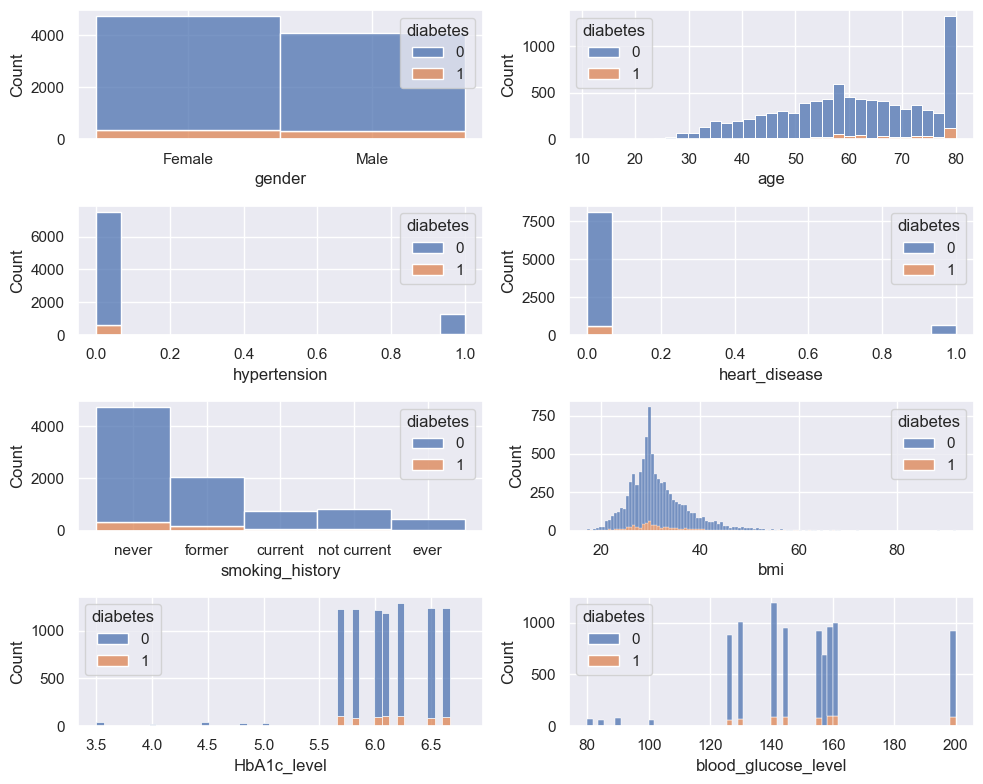

In [94]:
plot_cluster_histograms(2, df_test_for_histograms, clusters_scaled, Xcol)

Le groupe 2 constitue le pont entre les deux amas des sujets sains et diabétiques.

<div style="
    background-color:#fff3cd;
    border-left:6px solid #ffecb5;
    padding:20px;
    border-radius:6px;
">
<h2 style="margin-top:0; font-weight:bold;">
⚠️ ATTENTION
</h2>

<p style="font-size:1.4em; font-weight:bold;">
Voici une section fondamentale du tutoriel.
<br><br>
</p>
</div>

## Partie V: Interprétation des résultats

<p>&nbsp;</p>
<div align="center">
    <img src= "Images/medecine-personel.png"  width="300" />
</div>
<p>&nbsp;</p>

### Génération d'un tableau récapitulatif

Génération d'un résumé qualitatif des caractéristiques pour chaque cluster. Cela permet de synthétiser plus facilement les observations que l'on pourrait faire à partir des histogrammes.

In [95]:
def categorize_value(value, thresholds, labels):
    """Retourne une catégorie qualitative selon des seuils."""
    for t, lab in zip(thresholds, labels):
        if value < t:
            return lab
    return labels[-1]

def summarize_cluster(df_cluster):
    """Retourne un résumé qualitatif des caractéristiques d'un cluster."""
    
    # Moyennes
    mean_hba1c = df_cluster["HbA1c_level"].mean()
    mean_glucose = df_cluster["blood_glucose_level"].mean()
    mean_age = df_cluster["age"].mean()
    mean_bmi = df_cluster["bmi"].mean()
    hypertension_rate = df_cluster["hypertension"].mean() * 100
    
    # Catégorisation qualitative
    hba1c_cat = categorize_value(mean_hba1c,
                                 thresholds=[5.7, 6.5],
                                 labels=["Faibles", "Modérés", "Grands"])
    
    glucose_cat = categorize_value(mean_glucose,
                                   thresholds=[100, 140],
                                   labels=["Faibles", "Modérés", "Grands"])
    
    age_cat = categorize_value(mean_age,
                               thresholds=[30, 40, 60],
                               labels=["< 30 ans", "30–40 ans", "> 40 ans", "> 60 ans"])
    
    bmi_cat = categorize_value(mean_bmi,
                               thresholds=[25, 30, 35],
                               labels=["< 25", "25–30", "~ 30", "~ 35", "> 35"])
    
    hypertension_cat = categorize_value(hypertension_rate,
                                        thresholds=[10, 30, 60],
                                        labels=["Peu", "Modérée", "Beaucoup", "Très élevée"])
    
    # Description automatique
    description = (
        f"Moyenne HbA1c {hba1c_cat.lower()}, glucose {glucose_cat.lower()}, "
        f"âge {age_cat}, IMC {bmi_cat}, hypertension {hypertension_cat.lower()}."
    )
    
    return {
        "HbA1c Level": hba1c_cat,
        "Blood Glucose Level": glucose_cat,
        "Âge": age_cat,
        "BMI": bmi_cat,
        "Hypertension": hypertension_cat,
        "Description": description
    }


# --- Construction du tableau final ---

cluster_characteristics = {}

for entry in cluster_summary_data:
    cid = entry["Cluster ID"]
    df_cluster = df_test_for_histograms[clusters_scaled == cid]
    
    # Statistiques qualitatives
    stats = summarize_cluster(df_cluster)
    
    # Ajout des pourcentages déjà calculés
    stats["% Diabétiques"] = entry["% Diabétiques"]
    stats["% du total groupé"] = entry["% du total groupé"]
    
    cluster_characteristics[cid] = stats

cluster_characteristics

{0: {'HbA1c Level': 'Faibles',
  'Blood Glucose Level': 'Modérés',
  'Âge': '30–40 ans',
  'BMI': '25–30',
  'Hypertension': 'Peu',
  'Description': 'Moyenne HbA1c faibles, glucose modérés, âge 30–40 ans, IMC 25–30, hypertension peu.',
  '% Diabétiques': '0.55 %',
  '% du total groupé': '80.33 %'},
 1: {'HbA1c Level': 'Grands',
  'Blood Glucose Level': 'Grands',
  'Âge': '> 60 ans',
  'BMI': '~ 30',
  'Hypertension': 'Beaucoup',
  'Description': 'Moyenne HbA1c grands, glucose grands, âge > 60 ans, IMC ~ 30, hypertension beaucoup.',
  '% Diabétiques': '73.04 %',
  '% du total groupé': '10.50 %'},
 2: {'HbA1c Level': 'Modérés',
  'Blood Glucose Level': 'Grands',
  'Âge': '> 60 ans',
  'BMI': '~ 30',
  'Hypertension': 'Modérée',
  'Description': 'Moyenne HbA1c modérés, glucose grands, âge > 60 ans, IMC ~ 30, hypertension modérée.',
  '% Diabétiques': '7.58 %',
  '% du total groupé': '9.16 %'}}

Affichons un tableau des résultats qui sera plus facile à interpréter.

In [96]:
comparison_table = pd.DataFrame.from_dict(cluster_characteristics, orient='index')

print("Tableau comparatif des caractéristiques des clusters :")
display(comparison_table)

Tableau comparatif des caractéristiques des clusters :


,HbA1c Level,Blood Glucose Level,Âge,BMI,Hypertension,Description,% Diabétiques,% du total groupé
0,Faibles,Modérés,30–40 ans,25–30,Peu,"Moyenne HbA1c faibles, glucose modérés, âge 30...",0.55 %,80.33 %
1,Grands,Grands,> 60 ans,~ 30,Beaucoup,"Moyenne HbA1c grands, glucose grands, âge > 60...",73.04 %,10.50 %
2,Modérés,Grands,> 60 ans,~ 30,Modérée,"Moyenne HbA1c modérés, glucose grands, âge > 6...",7.58 %,9.16 %


### Analyse des données du tableau récapitulatif

On utilise le prompt suivant avec Copilot:

*Voici le dictionnaire décrivant les statistiques observées chez trois groupes de sujets dans une analyse des données sur le diabète :*

{0: {'HbA1c Level': 'Faibles',
  'Blood Glucose Level': 'Modérés',
  'Âge': '30–40 ans',
  'BMI': '25–30',
  'Hypertension': 'Peu',
  'Description': 'Moyenne HbA1c faibles, glucose modérés, âge 30–40 ans, IMC 25–30, hypertension peu.',
  '% Diabétiques': '0.55 %',
  '% du total groupé': '80.33 %'},
 1: {'HbA1c Level': 'Grands',
  'Blood Glucose Level': 'Grands',
  'Âge': '> 60 ans',
  'BMI': '~ 30',
  'Hypertension': 'Beaucoup',
  'Description': 'Moyenne HbA1c grands, glucose grands, âge > 60 ans, IMC ~ 30, hypertension beaucoup.',
  '% Diabétiques': '73.04 %',
  '% du total groupé': '10.50 %'},
 2: {'HbA1c Level': 'Modérés',
  'Blood Glucose Level': 'Grands',
  'Âge': '> 60 ans',
  'BMI': '~ 30',
  'Hypertension': 'Modérée',
  'Description': 'Moyenne HbA1c modérés, glucose grands, âge > 60 ans, IMC ~ 30, hypertension modérée.',
  '% Diabétiques': '7.58 %',
  '% du total groupé': '9.16 %'}}

*Tu es un chercheur médical sur le diabète. En te basant sur le tableau précédent, interprète les différences entre les 3 groupes, en expliquant ce que ces distinctions pourraient impliquer dans un contexte réel en ce qui concerne l'état de la maladie et les facteurs de risque.
Sauvegarde la réponse à ma question dans un fichier Word avec le nom suivant : ‘Diagnostic de Copilot sur les groupes obtenus dans l'analyse du diabète.docx’?*



---
## Partie IV : Conclusion
---

<p>&nbsp;</p>
<div align="center">
    <img src= "Images/union-fait-la-force.jpeg"  width="500" />
</div>
<p>&nbsp;</p>

Dans ce tutoriel, nous avons vu comment utiliser l'apprentissage automatique pour analyser des données contenues dans un fichier CSV.
Il aurait également été possible d'extraire les mêmes données d'un fichier Excel.

Nous avons vu qu'il y avait beaucoup d'étapes, dont l'ordre d'exécution est également important.

Dans un projet typique d'apprentissage automatique, le prétraitement des données peut représenter plus de 50 % des efforts investis ! L'entraînement et la sélection du meilleur modèle de classification parmi plusieurs sont généralement plus rapides.

L'analyse des résultats, et plus particulièrement leur interprétabilité, permet de mieux comprendre le phénomène étudié, que l'on soit médecin, ingénieur, pédagogue, etc. Dans le cas du diabète, le phénomène est vraiment non linéaire ; les méthodes statistiques standard n'auraient pas permis d'exposer autant de détails.

Au fil des ans, la partie la plus intéressante d'un projet est devenue l'utilisation des valeurs SHAP pour effectuer une analyse de groupe. On applique des plongements de données (*data embeddings*) aux valeurs SHAP, puis on effectue des regroupements de données (*cluster analysis*) pour identifier des groupes naturels de données. L'analyse des variables correspondantes permet de déterminer la nature de chaque groupe et leurs caractéristiques. Cette technique est utilisée pour l'analyse de marché, l'identification de différentes variantes d'une maladie (comme le diabète), etc.


### Remarques finales

Les résultats présentés dans ce tutoriel ne sont valables que pour la base de données utilisée. De plus, l'ordre précis des variables importantes peut légèrement varier en fonction du type de prétraitement ou de classificateur utilisé.

Le tutoriel étant déjà assez long, nous nous sommes limités à l'essentiel. Toutefois, pour une analyse plus poussée, par exemple dans le cadre de vos propres recherches (maîtrise, doctorat, postdoctorat, etc.), nous aurions pu ajouter les éléments suivants :

- Comparer plusieurs modèles de classificateurs afin d'identifier le meilleur (après l'optimisation des hyperparamètres de chacun). Après tout, nous n'avons utilisé que XGBoost.
- Au moyen du regroupement des données (DBSCAN), scinder le groupe des diabétiques (#1) en sous-groupes. Cela permettrait d'identifier diverses sous-populations sensibles au diabète ou encore divers types de diabète. Il faudrait ensuite demander à un expert humain ou à un chatbot d'interpréter les résultats obtenus.

**Il est important de mentionner que le même type d'analyse aurait pu être appliqué dans le cadre d'un projet en psychologie, en pédagogie, en astronomie, etc. en autant que les données soit disponibles sous forme tabulaire.**